# Week 4 — Basic Backtesting

[Open in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/week4_main.ipynb). If unavailable, download this notebook and upload it to Colab.

## Core financial question

When a signal becomes available, when can the position change, and which subsequent price return belongs to that position?

Week 3 constructed features and signals. We now connect them to execution assumptions, positions, trades, gross price returns and wealth. A correct multiplication is not enough: the position must exist at the beginning of the return interval. We first fix that timeline, then calculate and audit the ledger.

This lesson tests accounting under explicit assumptions. It does not establish actual fills or investment value. Week 5 adds estimated predictions; Week 6 adds costs; Week 7 evaluates risk and uncertainty.

## What you will learn

- Trace a signal through a later assumed execution and a subsequent holding interval.
- Calculate positions, entries, exits, exposure changes, gross returns and wealth.
- Detect early return attribution and missing exposed returns.
- Distinguish a final interval's position from a later liquidation or pending signal.
- Compare a fixed rule with buy and hold using the same price intervals.

Use the Week 3 Python environment with pandas, NumPy, matplotlib and yfinance. Run all cells in order. Each example asks for a prediction, displays its calculation, then interprets the output. Only assigned practices or Case 4 need to be submitted.

# How the issues connect

| Issues | Question | Why it comes here |
|---|---|---|
| 1–4 | What happens before, at and after execution? | A signal cannot earn returns from before entry. |
| 5–9 | Which positions and trades follow from the rule? | Initialization, entry, exit and exposure units must be explicit. |
| 10–13 | How do those columns produce a consistent wealth path? | Build the ledger and check each accounting identity. |
| 14–16 | What happens when timing, data or the final boundary changes? | Test failure cases before using an endpoint. |
| 17–18 | What must remain fixed in a benchmark or holdings calculation? | Comparisons require matching dates and beginning exposures. |
| 19–20 | Can another reader reconstruct and challenge the result? | Preserve the few necessary assumptions and test the resulting columns. |

The three practices isolate timing, missingness and terminal treatment. Case 4 combines them. Weight selection remains in Week 8.

# Execution and data assumptions

**Main convention:** a signal formed after close on date $d$ is assumed available in time for execution at the next stored close, $d+1$. It controls the position over $d+1$ close to $d+2$ close. Thus a return row ending at $t$ uses the signal from $t-2$, not $t-1$. These offsets count ordered observations, not calendar days.

For example, a Monday-after-close signal is assumed executed Tuesday at the close. Its first holding return ends Wednesday at the close. Tuesday's close-to-close return began Monday at the close, before the signal existed, so it is not earned by this new position.

The calculation uses the later closing price as an assumed execution price. It does not show that an order actually traded at a closing auction. Published prices, order submission deadlines, data arrival and real execution are different facts. [Investor.gov's order guidance](https://www.investor.gov/introduction-investing/investing-basics/how-stock-markets-work/types-orders) explains why a quoted or last-traded price is not a guaranteed execution price.

Positions are either 0 (zero-return cash) or 1 (fully exposed). Costs, taxes, dividends and external cash flows are excluded. All wealth here is **gross price-only wealth**, not an investor's total return. No position update or liquidation is appended after the last evaluated interval.

AAPL requests cover January 2–June 28, 2024; Issue 18 also uses MSFT. Yahoo's Close is split-adjusted; Adj Close additionally incorporates applicable distribution adjustments. Setting `auto_adjust=False` does not undo provider adjustments. This lesson uses Close ratios, not dividend-inclusive returns. Present downloads cannot prove historical data versions or delivery times. Public outputs retain dates, summaries and derived values rather than raw market price rows. See [Yahoo's field explanation](https://help.yahoo.com/kb/SLN2311.html).

Artificial examples have prices in currency units per share and consecutive artificial sessions, with no corporate actions. Their business-day labels are not an exchange calendar. For source examples, row offsets mean stored observations; claiming consecutive exchange sessions requires a separate calendar and security-status check.

In [1]:
# Purpose: load shared packages, validate price inputs and define the stated ledger calculations.
from importlib.metadata import PackageNotFoundError, version
import platform
from datetime import datetime, timezone

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

try:
    import yfinance as yf
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 150)
plt.rcParams.update(
    {
        "figure.figsize": (7.6, 3.8),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

US_HISTORY_REQUEST = {
    "start": "2024-01-02",
    "end": "2024-07-01",
    "interval": "1d",
    "auto_adjust": False,
    "actions": False,
    "progress": False,
    "threads": False,
    "multi_level_index": False,
}
_US_HISTORY_CACHE = {}


def load_us_daily(symbol):
    # Return a copy of one fixed response without displaying all downloaded rows.
    if yf is None:
        raise ModuleNotFoundError("Install yfinance before running a source-grounded Week 4 example.")
    if symbol not in _US_HISTORY_CACHE:
        rows = yf.download(tickers=symbol, **US_HISTORY_REQUEST)
        if isinstance(rows.columns, pd.MultiIndex):
            rows.columns = rows.columns.get_level_values(0)
        rows.index = pd.DatetimeIndex(rows.index).tz_localize(None)
        required = {"Open", "High", "Low", "Close", "Volume"}
        if len(rows) < 8 or not required.issubset(rows.columns):
            raise ValueError(f"The recorded {symbol} request returned no usable OHLCV response.")
        if not rows.index.is_monotonic_increasing or rows.index.isna().any():
            raise ValueError("Stop: dates must be ordered and valid.")
        if not ((rows.index >= pd.Timestamp(US_HISTORY_REQUEST["start"])) & (rows.index < pd.Timestamp(US_HISTORY_REQUEST["end"]))).all():
            raise ValueError("Stop: a returned date is outside the request.")
        prices = rows[["Open", "Close"]]
        if not np.isfinite(prices.to_numpy()).all() or not prices.gt(0).all().all():
            raise ValueError("Stop: this ledger requires finite positive price endpoints.")
        if not rows.index.is_unique:
            raise ValueError(f"The recorded {symbol} response contains duplicate dates.")
        _US_HISTORY_CACHE[symbol] = rows
    return _US_HISTORY_CACHE[symbol].copy()


def calculate_gross_return(position, asset_return):
    # Missing asset returns cannot be replaced while the portfolio is exposed.
    if not position.index.equals(asset_return.index):
        raise ValueError("Stop: position and return indexes differ.")
    if not position.isin([0.0, 1.0]).all():
        raise ValueError("Stop: position must be finite and either zero or one.")
    exposed = position.eq(1.0)
    if not np.isfinite(asset_return.loc[exposed]).all():
        raise ValueError("Stop: an exposed return is missing or nonfinite.")
    result = pd.Series(0.0, index=position.index)
    result.loc[exposed] = asset_return.loc[exposed]
    if (result <= -1).any():
        raise ValueError("Stop: this positive-wealth example excludes total loss.")
    return result


def build_long_cash_ledger(symbol="AAPL"):
    # Build the stated gross ledger; the function does not estimate a model or transaction costs.
    rows = load_us_daily(symbol)
    ledger = rows[["Open", "Close"]].copy()
    ledger["asset_return"] = ledger["Close"].pct_change(fill_method=None)
    ledger["momentum_5"] = ledger["Close"] / ledger["Close"].shift(5) - 1
    ledger["signal_after_close"] = np.where(ledger["momentum_5"].isna(), np.nan, np.where(ledger["momentum_5"] > 0, 1.0, 0.0))
    ledger["position"] = ledger["signal_after_close"].shift(2).fillna(0.0)
    ledger["signed_trade"] = ledger["position"] - ledger["position"].shift(1).fillna(0.0)
    ledger["absolute_trade"] = ledger["signed_trade"].abs()
    ledger["strategy_return_gross"] = calculate_gross_return(ledger["position"], ledger["asset_return"])
    labels = pd.Series(ledger.index, index=ledger.index)
    ledger["signal_date_controlling_interval"] = labels.shift(2)
    ledger["execution_boundary"] = labels.shift(1)
    ledger["return_end"] = labels
    ledger["strategy_wealth_gross"] = (1 + ledger["strategy_return_gross"]).cumprod(skipna=False)
    benchmark_position = pd.Series(1.0, index=ledger.index)
    benchmark_position.iloc[0] = 0.0
    ledger["buy_hold_return_gross"] = calculate_gross_return(benchmark_position, ledger["asset_return"])
    ledger["buy_hold_wealth_gross"] = (1 + ledger["buy_hold_return_gross"]).cumprod()
    return ledger


def show_figure_with_alt_text(figure, alt_text):
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}, "alt": alt_text.strip()})
    plt.close(figure)
    display(Markdown("**Figure.** " + alt_text.strip()))


environment = pd.Series(
    {
        "Run start UTC": datetime.now(timezone.utc).isoformat(),
        "Python interface": "Jupyter kernel",
        "Python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": mpl.__version__,
        "yfinance": YFINANCE_VERSION,
    },
    name="Value",
)
display(environment.rename_axis("Environment item").to_frame())

,Value
Environment item,
Run start UTC,2026-09-08T01:14:51.240951+00:00
Python interface,Jupyter kernel
Python,3.12.9
numpy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0


## Issue 1 — What must be fixed before a backtest starts?


A backtest is an implementation of a written decision rule, not merely a loop over prices. Before any return is calculated, the design must state the data frequency, signal time, decision time, execution boundary, holding return, permitted positions, cash return, entry and exit rules, position limits, missing-information rule, cost status, and terminal boundary.

These choices determine which return a position can earn. If they are filled in after the results are inspected, the design has already used evaluation evidence. The Week 4 specification below is deliberately narrow: one artificial asset, a signal known after a row's close, next-close execution followed by exposure, long or cash, zero cash return, and no forced liquidation.

The specification is not evidence that the assumed execution price would be available in a real market. It is the claim that the artificial ledger will implement and test for internal consistency.


### Connection to a documented source

The AAPL example uses a fixed yfinance request and Nasdaq's documented regular-session boundary. The source records identify the requested rows and a market boundary; the analyst must still specify the signal time, permitted position, execution assumption, holding return, cash rule, and terminal rule before seeing the result.

Sources: [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which written fields make a same-close implementation invalid.

In [2]:
# Purpose: What must be fixed before a backtest starts — controlled example.
strategy_specification = pd.DataFrame(
    [
        ("Data frequency", "One artificial observation per business-day label"),
        ("Signal time", "After the closing boundary of row t"),
        ("Decision time", "After the row-t signal is calculated"),
        ("Earliest execution", "Close at t+1, assuming the signal is already available"),
        ("Holding return", "Close at t+1 to Close at t+2"),
        ("Permitted positions", "0 for cash or 1 for long exposure"),
        ("Entry rule", "Position changes from 0 to 1 after the signal from two return rows earlier of 1"),
        ("Exit rule", "Position changes from 1 to 0 after the signal from two return rows earlier of 0"),
        ("Cash return", "0 in Week 4"),
        ("Unavailable signal", "Remain in cash"),
        ("Transaction costs", "0; gross backtest only"),
        ("Terminal boundary", "Report the final position; do not force liquidation"),
    ],
    columns=["Design field", "Week 4 rule"],
)
display(strategy_specification.style.hide(axis="index").set_caption("Prespecified Week 4 strategy rules"))

required_spec_fields = {
    "Signal time", "Decision time", "Earliest execution", "Holding return",
    "Permitted positions", "Entry rule", "Exit rule", "Cash return",
    "Unavailable signal", "Transaction costs", "Terminal boundary",
}
assert required_spec_fields.issubset(set(strategy_specification["Design field"]))

Design field,Week 4 rule
Data frequency,One artificial observation per business-day label
Signal time,After the closing boundary of row t
Decision time,After the row-t signal is calculated
Earliest execution,"Close at t+1, assuming the signal is already available"
Holding return,Close at t+1 to Close at t+2
Permitted positions,0 for cash or 1 for long exposure
Entry rule,Position changes from 0 to 1 after the signal from two return rows earlier of 1
Exit rule,Position changes from 1 to 0 after the signal from two return rows earlier of 0
Cash return,0 in Week 4
Unavailable signal,Remain in cash


### Interpret Code 1


The table shows which return interval the position is allowed to earn. A row-$t$ signal cannot earn a return that ended at the row-$t$ close because both the signal calculation and decision occur afterward. The first eligible exposure begins at the next close and earns the interval ending one close later.

Zero costs are a scope choice, not a realistic market estimate. The reported wealth later in this notebook is therefore gross. The terminal rule also matters: forcing a final sale would add a trade that the current specification does not contain.

### Source-grounded example

Code 2 records the fixed AAPL request and the analyst-created backtest assumptions separately. Fields that the request cannot establish remain explicitly unresolved.

### Before Code 2

Predict whether the AAPL record leaves execution price and provider publication time unresolved.

In [3]:
# Purpose: What must be fixed before a backtest starts — source example.
aapl_source = load_us_daily("AAPL")
real_specification = pd.DataFrame(
    [
        ("Requested symbol", "AAPL", "Recorded request"),
        ("Requested date boundary", f"{US_HISTORY_REQUEST['start']} inclusive to {US_HISTORY_REQUEST['end']} exclusive", "Recorded request"),
        ("Returned rows", len(aapl_source), "Returned response"),
        ("Returned first and last dates", f"{aapl_source.index.min().date()} to {aapl_source.index.max().date()}", "Returned response"),
        ("Signal time", "After each stored Close", "Analyst assumption"),
        ("Position rule", "Signal from two rows earlier; initial cash", "Analyst assumption"),
        ("Permitted position", "0 or 1", "Analyst assumption"),
        ("Transaction costs", "0; gross return only", "Week 4 scope"),
        ("Provider publication time", "Unresolved", "Not established by request"),
        ("Real execution price", "Unresolved", "No order or fill record"),
    ],
    columns=["Item", "Recorded value", "Evidence type"],
)
display(real_specification.style.hide(axis="index").set_caption("AAPL request facts and prespecified backtest assumptions"))
assert real_specification.loc[real_specification["Item"].eq("Real execution price"), "Recorded value"].item() == "Unresolved"

Item,Recorded value,Evidence type
Requested symbol,AAPL,Recorded request
Requested date boundary,2024-01-02 inclusive to 2024-07-01 exclusive,Recorded request
Returned rows,124,Returned response
Returned first and last dates,2024-01-02 to 2024-06-28,Returned response
Signal time,After each stored Close,Analyst assumption
Position rule,Signal from two rows earlier; initial cash,Analyst assumption
Permitted position,0 or 1,Analyst assumption
Transaction costs,0; gross return only,Week 4 scope
Provider publication time,Unresolved,Not established by request
Real execution price,Unresolved,No order or fill record


### Interpret Code 2


The fixed request returned 124 AAPL rows from 2024-01-02 through 2024-06-28 for the half-open request ending 2024-07-01. The table separates returned facts from analyst choices: signal time, the two-row signal lag, positions 0 or 1, and zero transaction costs are stated assumptions. Provider publication time and a real execution price remain unresolved, so the table supports a reproducible request and proposed gross ledger, not a fill claim.

### Discussion questions

1. A signal is calculated from AAPL data after the 16:00 Eastern Time regular-session close. The team assumes execution at that same closing price. Identify the unavailable event that invalidates the assumption, state the earliest replacement boundary, and name the evidence still needed before claiming a real fill.
2. Two teams use the same AAPL prices and signal. Team A permits only 0 or 1 positions and remains in cash before the first signal; Team B permits fractional positions and begins long. Identify at least four ledger fields that must differ and explain why their gross returns cannot be attributed to the signal rule alone.

## Issue 2 — Which interval does a return row represent?


A return stored on row $t$ describes the change between two boundaries, not an event that begins and ends on row $t$. Let $P_t$ be the closing price in currency units per share (USD per share for AAPL) at the end of interval $t$. The simple price return is dimensionless:

$$
r_{a,t}=\frac{P_t-P_{t-1}}{P_{t-1}}=\frac{P_t}{P_{t-1}}-1.
$$

In this lesson, `asset_return[t]` is the price change from row $t-1$ to row $t$. A signal calculated after the row-$t$ close is therefore too late to earn that return.

The safest audit expands each return into a beginning boundary, ending boundary, and observation pair. Once the interval is visible, the question is not whether the code contains a shift but whether the position was fixed before the interval began.

The controlled example uses two instructor-created intervals. Code 2 then uses the first returned AAPL interval without assigning a signal or claiming a historical strategy.


### Connection to a documented source

The yfinance response labels each AAPL daily row by date and supplies price endpoints. Pandas documents fractional change. Neither source changes the fact that a return ending on date t requires the price from the preceding stored observation.

Sources: [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict both interval returns and the latest permissible position boundary.

In [4]:
# Purpose: Which interval does a return row represent — controlled example.
interval_example = pd.DataFrame(
    {
        "Beginning boundary": ["Artificial row A close", "Artificial row B close"],
        "Ending boundary": ["Artificial row B close", "Artificial row C close"],
        "Beginning price": [100.0, 103.0],
        "Ending price": [103.0, 101.0],
    },
    index=["Artificial interval 1", "Artificial interval 2"],
)
interval_example["Simple price return"] = (
    interval_example["Ending price"] / interval_example["Beginning price"] - 1
)
display(interval_example.style.format({"Simple price return": "{:.4%}"}).set_caption("Returns with explicit beginning and ending boundaries"))

assert np.isclose(interval_example.loc["Artificial interval 1", "Simple price return"], 0.03)
assert np.isclose(interval_example.loc["Artificial interval 2", "Simple price return"], 101 / 103 - 1)

,Beginning boundary,Ending boundary,Beginning price,Ending price,Simple price return
Artificial interval 1,Artificial row A close,Artificial row B close,100.000000,103.000000,3.0000%
Artificial interval 2,Artificial row B close,Artificial row C close,103.000000,101.000000,-1.9417%


### Interpret Code 1


Artificial interval 1 returns 3.0000% from 100 to 103 price units. Artificial interval 2 returns -1.9417% from 103 to 101 price units. Both rows are labeled by an ending boundary but require the preceding price. A position that earns either return must be established no later than the beginning boundary under this simplified Close-to-Close convention.

The calculation is price-only and ignores distributions, costs, and execution feasibility. Its purpose is to make the interval visible before the signal is aligned.

### Source-grounded example

Code 2 expands the first AAPL Close-to-Close return into its beginning date, ending date, field names and derived return.

### Before Code 2

Predict the first AAPL Close-to-Close return and its two endpoint dates.

In [5]:
# Purpose: Which interval does a return row represent — source example.
aapl_source = load_us_daily("AAPL")
begin_date, end_date = aapl_source.index[:2]
begin_close = float(aapl_source.loc[begin_date, "Close"])
end_close = float(aapl_source.loc[end_date, "Close"])
real_interval = pd.DataFrame(
    [{"Beginning date": str(begin_date.date()), "Ending date": str(end_date.date()), "Field": "Yahoo Close; split-adjusted, not dividend-adjusted", "Simple price return": end_close / begin_close - 1}]
)
display(real_interval.style.hide(axis="index").format({"Simple price return": "{:.4%}"}).set_caption("First returned AAPL Close-to-Close interval"))
assert np.isclose(real_interval["Simple price return"].item(), aapl_source["Close"].pct_change(fill_method=None).iloc[1])

Beginning date,Ending date,Field,Simple price return
2024-01-02,2024-01-03,"Yahoo Close; split-adjusted, not dividend-adjusted",-0.7488%


### Interpret Code 2


The first returned AAPL interval runs from the 2024-01-02 Close to the 2024-01-03 Close. The simple price return is -0.7488%. A signal calculated after the January 3 Close is too late to earn this interval because the ending price is already known when that signal is formed.

### Discussion questions

1. An AAPL return is labeled 2024-01-03 but the beginning date is missing. State the two price endpoints required to interpret that return, then decide whether a signal calculated after the 2024-01-03 close may earn it and explain why.
2. One file stores next-open-to-close returns and another stores prior-close-to-close returns under the same ending date. Specify the price columns and beginning boundary for each, then state the check that must occur before the files can be compared.

## Issue 3 — How are signal, position, trade, return, and wealth different?


The central backtest objects have different financial meanings. A signal is the output of a rule. A position is the exposure held during a return interval. A trade is a change in position at a stated boundary. An asset return belongs to the asset over an interval. A strategy return combines the position and same-interval asset return. Wealth compounds the ordered strategy returns from an initial value.

Using one name such as `strategy` for all of these objects hides timing and accounting mistakes. A complete ledger keeps separate columns and records when each becomes known.

The following table explains what each column contains and when its value is known. It does not calculate strategy returns.


### Connection to a documented source

Pandas documents the arithmetic operations used for lagging, differencing, multiplication, and compounding. Those operations do not make a signal, position, trade, return, and wealth interchangeable; the financial meaning comes from the written strategy and interval definitions.

Sources: [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html); [pandas difference documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html); [pandas cumulative-product documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.cumprod.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which objects are states and which multiplication produces gross strategy return.

In [6]:
# Purpose: How are signal, position, trade, return, and wealth different — controlled example.
object_roles = pd.DataFrame(
    [
        ("signal_at_close", "Rule output", "After row-t close", "No"),
        ("position", "Exposure held during one later return interval", "Before the interval", "Yes"),
        ("trade", "Signed or absolute binary exposure change", "At the position-change boundary", "No"),
        ("asset_return", "Asset price change over one interval", "At interval end", "No"),
        ("strategy_return_gross", "Position times same-interval asset return", "At interval end", "No"),
        ("strategy_wealth_gross", "Compounded gross strategy returns", "After each interval", "Yes"),
    ],
    columns=["Ledger object", "Financial meaning", "Relevant time", "State variable"],
)
display(object_roles.style.hide(axis="index").set_caption("Distinct objects in a basic backtest"))

assert object_roles["Ledger object"].is_unique
assert set(object_roles.loc[object_roles["State variable"] == "Yes", "Ledger object"]) == {"position", "strategy_wealth_gross"}

Ledger object,Financial meaning,Relevant time,State variable
signal_at_close,Rule output,After row-t close,No
position,Exposure held during one later return interval,Before the interval,Yes
trade,Signed or absolute binary exposure change,At the position-change boundary,No
asset_return,Asset price change over one interval,At interval end,No
strategy_return_gross,Position times same-interval asset return,At interval end,No
strategy_wealth_gross,Compounded gross strategy returns,After each interval,Yes


### Interpret Code 1


Position and wealth are state variables: each describes a condition carried at a boundary. Here a trade column records a binary exposure change, not share quantity or USD notional. Return measures proportional value change over an interval. The gross strategy return is `position × asset_return` after both have been aligned to the same interval.

A signal is not automatically a position because the execution rule may delay, limit, or reject the requested exposure. Week 4 uses a direct long-or-cash mapping only after a two-row lag relative to the ending-return label.

### Source-grounded example

Code 2 selects the first AAPL entry and displays one controlling signal, the later position and trade, the same-interval asset and strategy returns, and resulting gross wealth.

### Before Code 2

Predict whether a signal date, execution date and first holding-return end can be the same date under the stated rule.

In [7]:
# Purpose: How are signal, position, trade, return, and wealth different — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
first_entry_date = aapl_ledger.index[aapl_ledger["signed_trade"].eq(1.0)][0]
entry_location = aapl_ledger.index.get_loc(first_entry_date)
signal_date = aapl_ledger.index[entry_location - 2]
real_objects = pd.Series(
    {
        "controlling signal date": str(signal_date.date()),
        "signal after close": aapl_ledger.loc[signal_date, "signal_after_close"],
        "assumed execution date": str(aapl_ledger.index[entry_location - 1].date()),
        "holding interval end date": str(first_entry_date.date()),
        "position": aapl_ledger.loc[first_entry_date, "position"],
        "signed trade": aapl_ledger.loc[first_entry_date, "signed_trade"],
        "asset return (%)": 100 * aapl_ledger.loc[first_entry_date, "asset_return"],
        "gross strategy return (%)": 100 * aapl_ledger.loc[first_entry_date, "strategy_return_gross"],
        "gross wealth": aapl_ledger.loc[first_entry_date, "strategy_wealth_gross"],
    },
    name="Observed value",
)
display(real_objects.to_frame().round(6))
assert aapl_ledger.loc[first_entry_date, "position"] == 1.0
assert np.isclose(aapl_ledger.loc[first_entry_date, "strategy_return_gross"], aapl_ledger.loc[first_entry_date, "asset_return"])

,Observed value
controlling signal date,2024-01-10
signal after close,1.0
assumed execution date,2024-01-11
holding interval end date,2024-01-12
position,1.0
signed trade,1.0
asset return (%),0.177812
gross strategy return (%),0.177812
gross wealth,1.001778


### Interpret Code 2

The controlling AAPL signal is 1 after the January 10, 2024 Close. Assumed execution is January 11 Close; the first exposed return ends January 12. Position and signed exposure change are both 1. The 0.177812% price return becomes the same gross strategy return, taking normalized wealth to 1.001778. The trade is dated January 11 even though the accounting row ends January 12; no actual fill is observed.

### Discussion questions

1. A ledger contains only `signal`, `asset_return`, and `wealth`. Identify the missing column needed to prove exposure during each interval and the missing column needed to measure changes in exposure. Give one timing or accounting error each omission could conceal.
2. A signal equals 1, a position limit produces exposure 0.5, and the same-interval asset return is 2%. State the signal, position, signed trade from cash, and gross strategy return. Explain why replacing the position with the signal changes the strategy.

## Issue 4 — How does an after-close signal become the next position?

The position for an interval must be established at its beginning. Let $s_d$ be the dimensionless signal computed after close $d$. The assumed execution is at close $d+1$, so that signal controls the close-$d+1$ to close-$d+2$ interval.

Let $p_t$ be the fraction of wealth exposed during the interval ending at close $t$. Replacing $d+2$ by $t$ gives $d=t-2$, hence

$$
p_t=s_{t-2}, \qquad
r_{a,t}=\frac{P_t}{P_{t-1}}-1.
$$

These are not universal trading formulas: the two-row lag follows from this particular execution rule and ending-date convention. An open-based strategy requires different endpoints and may require a different row mapping.

In the four artificial rows A–D, a signal of 1 after B is executed at C close and first earns the return ending at D. The return ending at C began at B close, before the signal existed. Even a one-row shift is too early for this convention.

We use initial cash when no controlling signal exists. The signal column itself stays missing.

### Connection to a documented source

Pandas documents that `shift(1)` moves stored values by one row. Nasdaq's regular-session boundary helps explain why a signal calculated after a close cannot control an interval that has already ended. A row shift is valid only after the dates and intended execution sequence have been checked.

Sources: [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation); [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the valid four-row position sequence under the two-row lag and first long row.

In [8]:
# Purpose: How does an after-close signal become the next position — controlled example.
lag_demo = pd.DataFrame(
    {
        "signal_at_close": [np.nan, 1.0, 0.0, 1.0],
        "asset_return": [np.nan, 0.02, -0.01, 0.03],
    },
    index=pd.Index(["A", "B", "C", "D"], name="Row"),
)
lag_demo["valid_position"] = lag_demo["signal_at_close"].shift(2).fillna(0.0)
lag_demo["invalid_same_row_position"] = lag_demo["signal_at_close"].fillna(0.0)
lag_demo["valid_gross_return"] = (lag_demo["valid_position"] * lag_demo["asset_return"]).fillna(0.0)
lag_demo["invalid_one_row_position"] = lag_demo["signal_at_close"].shift(1).fillna(0.0)
display(lag_demo.style.format({"asset_return": "{:.2%}", "valid_gross_return": "{:.2%}"}).set_caption("Signal-to-position lag on four artificial rows"))

assert lag_demo["valid_position"].tolist() == [0.0, 0.0, 0.0, 1.0]
assert lag_demo.loc["D", "valid_gross_return"] == 0.03

,signal_at_close,asset_return,valid_position,invalid_same_row_position,valid_gross_return,invalid_one_row_position
Row,,,,,,
A,nan,nan%,0.000000,0.000000,0.00%,0.000000
B,1.000000,2.00%,0.000000,1.000000,0.00%,0.000000
C,0.000000,-1.00%,0.000000,0.000000,-0.00%,1.000000
D,1.000000,3.00%,1.000000,1.000000,3.00%,0.000000


### Interpret Code 1


The first long position appears on row D: row B has the first signal of 1, execution occurs at C close, and the position earns D’s 3.0% asset return. Positions are 0, 0, 0, 1. The one-row version incorrectly holds 1 over B close to C close; the same-row version is earlier still.

The invalid column reacts too early. It may produce a numerically attractive or unattractive result; either direction is irrelevant because it violates the time order.

### Source-grounded example

Code 2 locates the first AAPL signal equal to 1 and confirms that it affects the position on the second later stored observation, after execution at the intervening close.

### Before Code 2

Predict whether the first return controlled by a positive signal ends one or two stored dates later.

In [9]:
# Purpose: How does an after-close signal become the next position — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
first_signal_one = aapl_ledger.index[aapl_ledger["signal_after_close"].eq(1.0)][0]
signal_location = aapl_ledger.index.get_loc(first_signal_one)
first_eligible_date = aapl_ledger.index[signal_location + 2]
real_lag = aapl_ledger.loc[aapl_ledger.index[signal_location - 1:signal_location + 3], ["momentum_5", "signal_after_close", "position", "asset_return"]]
display(real_lag.style.format({"momentum_5": "{:.3%}", "asset_return": "{:.3%}"}).set_caption("AAPL signal and the following stored position"))
lag_dates = pd.Series({"first signal equal to 1": str(first_signal_one.date()), "first return end controlled by that signal": str(first_eligible_date.date()), "same-row position": aapl_ledger.loc[first_signal_one, "position"], "position two rows later": aapl_ledger.loc[first_eligible_date, "position"]}, name="Observed value")
display(lag_dates.to_frame())
assert aapl_ledger.loc[first_eligible_date, "position"] == aapl_ledger.loc[first_signal_one, "signal_after_close"] == 1.0

,momentum_5,signal_after_close,position,asset_return
Date,,,,
2024-01-09 00:00:00,-0.269%,0.000000,0.000000,-0.226%
2024-01-10 00:00:00,1.053%,1.000000,0.000000,0.567%
2024-01-11 00:00:00,2.023%,1.000000,0.000000,-0.322%
2024-01-12 00:00:00,2.616%,1.000000,1.000000,0.178%


,Observed value
first signal equal to 1,2024-01-10
first return end controlled by that signal,2024-01-12
same-row position,0.0
position two rows later,1.0


### Interpret Code 2

The first AAPL signal of 1 occurs on January 10, 2024, with five-observation momentum of 1.053%. Its same-row position remains 0. The signal controls the return ending January 12, after the assumed January 11 close execution. That interval returns 0.178%. A one-row position would wrongly include January 10 close to January 11 close, which began before this signal existed.

### Discussion questions

1. After-close signals on five dates are `missing, 0, 1, 1, 0`. Derive the valid positions, identify every date on which a same-row implementation differs, and name the signal from two rows earlier that controls the first differing interval.
2. An AAPL table skips one expected market session. Decide whether `shift(1)` still means the next stored observation, the next exchange session, or both. Specify the calendar and timestamp evidence required before interpreting the lag financially.

## Issue 5 — What happens before the first signal is available?


An unavailable signal is not the same as a signal of zero. The former means the feature history or source value does not yet exist; the latter is an observed rule output. Week 4 must nevertheless choose an initial position. The required classroom rule remains in zero-return cash until the signal from two rows earlier is available.

This initialization prevents the notebook from inventing a long position. It does not erase the missing signal: the signal column remains missing so that the reason for initial cash can be audited.

Alternative initialization rules would define different strategies and must be chosen before evaluation.


### Connection to a documented source

A five-session AAPL momentum calculation has unavailable initial history. The missing values are consequences of the stated lookback, while the decision to remain in cash is a separate strategy rule rather than a value supplied by Yahoo Finance or pandas.

Sources: [pandas rolling-window documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict how many initial signal values remain missing and when the first long interval begins.

In [10]:
# Purpose: What happens before the first signal is available — controlled example.
initialization_demo = pd.DataFrame(
    {
        "mom_5": [np.nan, np.nan, np.nan, np.nan, np.nan, 0.02, -0.01, 0.01],
    },
    index=pd.date_range("2026-03-02", periods=8, freq="D"),
)
initialization_demo["signal_at_close"] = np.where(
    initialization_demo["mom_5"].isna(),
    np.nan,
    np.where(initialization_demo["mom_5"] > 0, 1.0, 0.0),
)
initialization_demo["position"] = initialization_demo["signal_at_close"].shift(2).fillna(0.0)
display(initialization_demo.style.format({"mom_5": "{:.2%}"}).set_caption("Missing feature history and explicit initial cash"))

assert initialization_demo["signal_at_close"].iloc[:5].isna().all()
assert initialization_demo["position"].iloc[:7].eq(0.0).all()
assert initialization_demo["position"].iloc[7] == 1.0

,mom_5,signal_at_close,position
2026-03-02 00:00:00,nan%,nan,0.000000
2026-03-03 00:00:00,nan%,nan,0.000000
2026-03-04 00:00:00,nan%,nan,0.000000
2026-03-05 00:00:00,nan%,nan,0.000000
2026-03-06 00:00:00,nan%,nan,0.000000
2026-03-07 00:00:00,2.00%,1.000000,0.000000
2026-03-08 00:00:00,-1.00%,0.000000,0.000000
2026-03-09 00:00:00,1.00%,1.000000,1.000000


### Interpret Code 1


The first five signals remain missing because five-session momentum is unavailable. The signal on the sixth row becomes 1, but the position stays in cash on that row because the signal is known only afterward. The seventh row ends at the assumed execution close; the eighth row is the first long holding interval.

The position column contains zeros during initialization because the strategy explicitly chooses cash. That decision must not be mistaken for observed zero signals.

### Source-grounded example

Code 2 shows the initial AAPL rows before five-session momentum exists. Missing feature and signal values are retained while the separate position rule keeps the portfolio in cash.

### Before Code 2

Predict the initial missing-signal count for five-observation momentum and whether a positive signal creates immediate exposure.

In [11]:
# Purpose: What happens before the first signal is available — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_initial = aapl_ledger[["momentum_5", "signal_after_close", "position"]].head(8)
display(real_initial.style.format({"momentum_5": "{:.3%}"}).set_caption("AAPL missing feature history and initial cash position"))
initial_summary = pd.Series(
    {
        "initial missing momentum rows": int(aapl_ledger["momentum_5"].isna().cumprod().sum()),
        "initial missing signal rows": int(aapl_ledger["signal_after_close"].isna().cumprod().sum()),
        "first available signal date": str(aapl_ledger["signal_after_close"].first_valid_index().date()),
        "first long-position date": str(aapl_ledger.index[aapl_ledger["position"].eq(1.0)][0].date()),
    },
    name="Observed value",
)
display(initial_summary.to_frame())
assert real_initial["signal_after_close"].iloc[:5].isna().all()
assert real_initial["position"].iloc[:6].eq(0.0).all()

,momentum_5,signal_after_close,position
Date,,,
2024-01-02 00:00:00,nan%,nan,0.000000
2024-01-03 00:00:00,nan%,nan,0.000000
2024-01-04 00:00:00,nan%,nan,0.000000
2024-01-05 00:00:00,nan%,nan,0.000000
2024-01-08 00:00:00,nan%,nan,0.000000
2024-01-09 00:00:00,-0.269%,0.000000,0.000000
2024-01-10 00:00:00,1.053%,1.000000,0.000000
2024-01-11 00:00:00,2.023%,1.000000,0.000000


,Observed value
initial missing momentum rows,5
initial missing signal rows,5
first available signal date,2024-01-09
first long-position date,2024-01-12


### Interpret Code 2

The output retains five missing momentum values and five missing signals. The first computable signal is January 9, 2024; the first signal of 1 occurs January 10. The first long holding interval ends January 12 after assumed execution at January 11 Close. These are different milestones: sufficient feature history is not the same as a positive signal or an executed position.

### Discussion questions

1. A team replaces five unavailable momentum values with zero and then creates signal 0. Identify which rows now claim a rule decision without the required history, and explain why remaining in cash does not require altering the missing signal values.
2. Choose one prespecified initialization rule for a new long-or-cash strategy: initial cash or inherited long exposure. State the evidence needed for the choice, its first-row position and trade, and why choosing after comparing endpoints would change the tested strategy.

## Issue 6 — What exactly triggers an entry and an exit?


An entry is a change from cash to long exposure. An exit is a change from long exposure to cash. The signal value alone does not identify either event because a repeated signal can leave the position unchanged.

Under the Week 4 rule, entries and exits are detected from consecutive positions after the signal has been lagged. A change from 0 to 1 has signed change +1; a change from 1 to 0 has signed change −1. The absolute change is 1 for either event and 0 when the position is held.

This event definition will later support turnover and costs, but Week 4 does not charge either event.


The row label marks the return end, not the trade time. A change in `position[t]` happens at close $t-1$ for the interval ending $t$. Keep that execution date alongside the end-date label.

### Connection to a documented source

The AAPL position sequence is created from the classroom rule. FINRA distinguishes orders, executions, and positions in its investor material; the entries and exits displayed here remain accounting events under the stated full-execution assumption, not evidence of actual fills.

Sources: [FINRA order types](https://www.finra.org/investors/investing/investment-products/stocks/order-types); [pandas difference documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the entries, exits, and long holding intervals in the artificial path.

In [12]:
# Purpose: What exactly triggers an entry and an exit — controlled example.
event_demo = pd.DataFrame(
    {"position": [0.0, 0.0, 1.0, 1.0, 0.0, 1.0]},
    index=pd.Index(range(6), name="Row"),
)
event_demo["signed_position_change"] = event_demo["position"].diff().fillna(event_demo["position"])
event_demo["absolute_position_change"] = event_demo["signed_position_change"].abs()
event_demo["event"] = np.select(
    [event_demo["signed_position_change"] > 0, event_demo["signed_position_change"] < 0],
    ["Entry", "Exit"],
    default="Hold",
)
display(event_demo.style.hide(axis="index").set_caption("Entries, exits, and held positions"))

event_summary = pd.Series(
    {
        "entries": int((event_demo["event"] == "Entry").sum()),
        "exits": int((event_demo["event"] == "Exit").sum()),
        "long_intervals": int(event_demo["position"].sum()),
        "position_changes": int((event_demo["absolute_position_change"] > 0).sum()),
    },
    name="Count",
)
display(event_summary.to_frame())
assert event_summary.to_dict() == {"entries": 2, "exits": 1, "long_intervals": 3, "position_changes": 3}

position,signed_position_change,absolute_position_change,event
0.000000,0.000000,0.000000,Hold
0.000000,0.000000,0.000000,Hold
1.000000,1.000000,1.000000,Entry
1.000000,0.000000,0.000000,Hold
0.000000,-1.000000,1.000000,Exit
1.000000,1.000000,1.000000,Entry


,Count
entries,2
exits,1
long_intervals,3
position_changes,3


### Interpret Code 1


Rows 2 and 5 are entries, row 4 is an exit, and row 3 is a hold. Three position changes and three long intervals happen to have the same count in this example, but they measure different objects and need not match on another path.

The first row is treated as an initial state, not an entry, because it begins in cash. A different initial-position rule would change this boundary treatment.

### Source-grounded example

Code 2 classifies AAPL position changes as entries or exits and counts long intervals separately from those events.

### Before Code 2

Predict which will be larger: long holding intervals or entries. Explain why a repeated long position need not add an entry.

In [13]:
# Purpose: What exactly triggers an entry and an exit — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_events = pd.Series(
    {
        "entries": int(aapl_ledger["signed_trade"].eq(1.0).sum()),
        "exits": int(aapl_ledger["signed_trade"].eq(-1.0).sum()),
        "holding rows with no position change": int((aapl_ledger["position"].eq(1.0) & aapl_ledger["signed_trade"].eq(0.0)).sum()),
        "long intervals": int(aapl_ledger["position"].eq(1.0).sum()),
    },
    name="Count",
)
event_rows = aapl_ledger.loc[aapl_ledger["signed_trade"].ne(0), ["signal_date_controlling_interval", "execution_boundary", "position", "signed_trade"]].head(8)
display(real_events.to_frame())
display(event_rows.style.set_caption("First AAPL position-change rows"))
assert real_events["long intervals"] >= real_events["entries"]

,Count
entries,15
exits,15
holding rows with no position change,48
long intervals,63


,signal_date_controlling_interval,execution_boundary,position,signed_trade
Date,,,,
2024-01-12 00:00:00,2024-01-10 00:00:00,2024-01-11 00:00:00,1.000000,1.000000
2024-01-18 00:00:00,2024-01-16 00:00:00,2024-01-17 00:00:00,0.000000,-1.000000
2024-01-22 00:00:00,2024-01-18 00:00:00,2024-01-19 00:00:00,1.000000,1.000000
2024-01-31 00:00:00,2024-01-29 00:00:00,2024-01-30 00:00:00,0.000000,-1.000000
2024-02-08 00:00:00,2024-02-06 00:00:00,2024-02-07 00:00:00,1.000000,1.000000
2024-02-14 00:00:00,2024-02-12 00:00:00,2024-02-13 00:00:00,0.000000,-1.000000
2024-02-26 00:00:00,2024-02-22 00:00:00,2024-02-23 00:00:00,1.000000,1.000000
2024-02-27 00:00:00,2024-02-23 00:00:00,2024-02-26 00:00:00,0.000000,-1.000000


### Interpret Code 2

The AAPL ledger has 15 entries, 15 exits and 63 long holding intervals. Of those intervals, 48 begin without a position change. The first entry executes at January 11 Close for the row ending January 12; the first exit executes at January 17 Close for the row ending January 18. Counting holding intervals as trades would confuse 63 exposures with 30 position changes.

### Discussion questions

1. Signals after the close are `1, 1, 0, 0, 1`, and the pre-sample position is cash. Derive the lagged positions, label every entry and exit, and explain why repeated signal 1 is not a second entry.
2. A sample begins with position 1 but does not record the pre-sample position. Compare classifying the first row as an entry, an inherited holding, and unresolved. State how each choice changes event counts and which conclusion must wait.

## Issue 7 — Which execution boundary connects a decision to a holding return?


An execution assumption connects the decision time with the beginning of the return interval. A next-open design and a next-close design do not earn the same holding return, even when they use the same after-close signal. The next-close design earns close $d+1$ to close $d+2$. A next-open, same-day-exit design earns open $d+1$ to close $d+1$ and excludes overnight exposure.

The artificial table compares two possible next-session designs while retaining next-close execution as the main notebook convention. The purpose is to show that an execution label changes both the required price field and the interval being evaluated.

Real fillability requires order type, liquidity, spread, queue, and market-mechanism evidence that Week 4 does not provide.


For entry price $P_{\mathrm{entry}}>0$ and exit price $P_{\mathrm{exit}}$, measured in the same currency per share and on the same share basis, a fixed positive quantity $q$ of shares gives the decimal price return $r$:

$$
r=\frac{qP_{\mathrm{exit}}-qP_{\mathrm{entry}}}{qP_{\mathrm{entry}}}
=\frac{P_{\mathrm{exit}}}{P_{\mathrm{entry}}}-1.
$$
The shares cancel; the price endpoints do not. This assumes no distributions, external flows or costs.

### Connection to a documented source

Nasdaq documents regular market hours, and the SEC explains that market orders generally seek immediate execution but do not guarantee a price. The AAPL example therefore compares two stated price intervals without claiming that either published price was available as a real fill.

Sources: [SEC trade-execution guidance](https://www.sec.gov/investor/pubs/tradexec.htm); [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the return under each artificial execution interval.

In [14]:
# Purpose: Which execution boundary connects a decision to a holding return — controlled example.
execution_example = pd.DataFrame(
    [
        {
            "Design": "Next open, exit next close",
            "Decision known": "After day 0 close",
            "Entry price": 101.0,
            "Exit price": 103.0,
            "Holding return": 103.0 / 101.0 - 1,
        },
        {
            "Design": "Next close, exit following close",
            "Decision known": "After day 0 close",
            "Entry price": 103.0,
            "Exit price": 102.0,
            "Holding return": 102.0 / 103.0 - 1,
        },
    ]
)
display(execution_example.style.format({"Holding return": "{:.3%}"}).hide(axis="index").set_caption("Two artificial execution and holding-return definitions"))

assert np.isclose(execution_example.loc[0, "Holding return"], 103 / 101 - 1)
assert np.isclose(execution_example.loc[1, "Holding return"], 102 / 103 - 1)

Design,Decision known,Entry price,Exit price,Holding return
"Next open, exit next close",After day 0 close,101.000000,103.000000,1.980%
"Next close, exit following close",After day 0 close,103.000000,102.000000,-0.971%


### Interpret Code 1


The next-open design earns approximately 1.980% from 101 to 103 currency units per share. The next-close design begins later at 103 currency units per share and earns approximately −0.971% to the following close of 102 currency units per share. These are different strategies, not two estimates of one return.

The table uses hypothetical prices and assumes full execution. Week 6 will add execution delay and cost sensitivity, but even that will not prove a real fill without order-level evidence.

### Source-grounded example

Code 2 uses the first AAPL signal equal to 1 to compare two explicitly different holding intervals. The displayed returns come from published price fields, not observed fills.

### Before Code 2

Predict whether the first AAPL long signal produces the same return under next-open-to-close and next-close-to-following-close definitions.

In [15]:
# Purpose: Which execution boundary connects a decision to a holding return — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
signal_date = aapl_ledger.index[aapl_ledger["signal_after_close"].eq(1.0)][0]
signal_location = aapl_ledger.index.get_loc(signal_date)
next_date = aapl_ledger.index[signal_location + 1]
following_date = aapl_ledger.index[signal_location + 2]
next_open = float(aapl_ledger.loc[next_date, "Open"])
next_close = float(aapl_ledger.loc[next_date, "Close"])
following_close = float(aapl_ledger.loc[following_date, "Close"])
real_execution = pd.DataFrame(
    [
        ("Next Open to next Close", str(next_date.date()), str(next_date.date()), next_close / next_open - 1),
        ("Next Close to following Close", str(next_date.date()), str(following_date.date()), following_close / next_close - 1),
    ],
    columns=["Stated interval", "Beginning date", "Ending date", "Price return"],
)
display(real_execution.style.hide(axis="index").format({"Price return": "{:.3%}"}).set_caption("Two AAPL price intervals after the first long signal"))
assert real_execution["Stated interval"].nunique() == 2

Stated interval,Beginning date,Ending date,Price return
Next Open to next Close,2024-01-11,2024-01-11,-0.509%
Next Close to following Close,2024-01-11,2024-01-12,0.178%


### Interpret Code 2


After the first AAPL signal equal to 1, the next Open-to-Close interval on 2024-01-11 returns -0.509%. The alternative 2024-01-11 Close-to-2024-01-12 Close interval returns 0.178%. The opposite signs arise because the price boundaries differ. The main ledger uses the second interval; it does not switch rules after seeing these results. The table contains price observations, not evidence that either price was an executable fill.

### Discussion questions

1. A signal is known after Monday's close. Compare a Tuesday-open-to-Tuesday-close design with a Tuesday-close-to-Wednesday-close design. Name every required price field and timestamp, and state why the resulting returns describe different strategies.
2. The next-open design has a positive return and the next-close design has a negative return. Decide whether this proves one execution rule is better. Identify the single changed factor and the common evidence needed for a controlled comparison.

## Issue 8 — How are long-or-cash position limits enforced?


A valid long-or-cash position must be finite and belong to the permitted set `{0, 1}`. A raw signal of 2, −1, or missing cannot be silently clipped or converted without a written rule. The backtest should stop on values that contradict the specification.

For every evaluated interval, the constraint is

$$
p_t \in \{0,1\}.
$$

The value 0 means cash under the stated zero cash-return assumption, and 1 means full exposure to the one asset. This constraint belongs to the Week 4 strategy; it is not a universal portfolio restriction.

This issue separates validation from transformation. Validation reports whether a candidate already satisfies the design. It does not repair the candidate. A later multi-asset weighting method will use different constraints, but Week 4 uses a single scalar exposure.

Stopping on an invalid position protects every later return and wealth calculation from an undefined exposure.


### Connection to a documented source

NumPy and pandas can test whether calculated positions are finite and belong to the permitted set. The long-or-cash constraint is an analyst decision; neither the data provider nor the software decides whether short selling, leverage, or fractional exposure is allowed.

Sources: [NumPy finite-value documentation](https://numpy.org/doc/stable/reference/generated/numpy.isfinite.html); [pandas membership documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.isin.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which candidate values satisfy the exact long-or-cash constraint.

In [16]:
# Purpose: How are long-or-cash position limits enforced — controlled example.
candidate_positions = pd.Series([0.0, 1.0, 0.5, -1.0, 2.0, np.nan], name="candidate_position")
position_validation = pd.DataFrame({"candidate_position": candidate_positions})
position_validation["finite"] = np.isfinite(position_validation["candidate_position"])
position_validation["permitted_long_or_cash"] = position_validation["candidate_position"].isin([0.0, 1.0])
position_validation["decision"] = np.where(
    position_validation["finite"] & position_validation["permitted_long_or_cash"],
    "Accept",
    "Stop and inspect",
)
display(position_validation.style.hide(axis="index").set_caption("Validation without silent clipping"))

assert position_validation["decision"].tolist() == ["Accept", "Accept", "Stop and inspect", "Stop and inspect", "Stop and inspect", "Stop and inspect"]

candidate_position,finite,permitted_long_or_cash,decision
0.000000,True,True,Accept
1.000000,True,True,Accept
0.500000,True,False,Stop and inspect
-1.000000,True,False,Stop and inspect
2.000000,True,False,Stop and inspect
nan,False,False,Stop and inspect


### Interpret Code 1


Only 0 and 1 pass. A value of 0.5 might be valid under a different fractional-position design, but it is invalid under the exact Week 4 specification. Missing means that a position rule has not produced an exposure; it is not accepted as cash unless the initialization rule explicitly supplies zero in a separate step.

Clipping −1 to 0 or 2 to 1 would hide a contradiction between the signal mapping and the position constraint. The appropriate action is to inspect and revise the design or upstream code.

### Source-grounded example

Code 2 validates the AAPL positions produced by the lagged binary signal. It reports invalid values instead of clipping or repairing them silently.

### Before Code 2

Predict whether every AAPL position is finite and belongs to the set containing only 0 and 1.

In [17]:
# Purpose: How are long-or-cash position limits enforced — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_position_check = pd.Series(
    {
        "position rows": len(aapl_ledger),
        "finite positions": int(np.isfinite(aapl_ledger["position"]).sum()),
        "positions equal to 0": int(aapl_ledger["position"].eq(0.0).sum()),
        "positions equal to 1": int(aapl_ledger["position"].eq(1.0).sum()),
        "invalid long-or-cash positions": int((~aapl_ledger["position"].isin([0.0, 1.0]) | ~np.isfinite(aapl_ledger["position"])).sum()),
    },
    name="Count",
)
display(real_position_check.to_frame())
assert real_position_check["invalid long-or-cash positions"] == 0
assert real_position_check["positions equal to 0"] + real_position_check["positions equal to 1"] == len(aapl_ledger)

,Count
position rows,124
finite positions,124
positions equal to 0,61
positions equal to 1,63
invalid long-or-cash positions,0


### Interpret Code 2

All 124 positions are finite: 61 equal 0 and 63 equal 1. The invalid-position count is zero. This validates the stored binary exposures, not the realism of their execution. The same check would reject a fractional position even if its return multiplication were arithmetically possible.

### Discussion questions

1. A model emits scores `-0.2, 0.4, 1.3`. Write one explicit mapping to positions 0 or 1. Explain why applying `clip(0, 1)` instead retains the fractional exposure 0.4 and violates the current constraint.
2. A position equals 0.999999 because of numerical arithmetic. Compare rejecting it, testing within a tolerance, and tracing its construction. Select one action for a discrete long-or-cash strategy and state how accepted values must be stored.

## Issue 9 — How is a trade measured from positions?


For a single long-or-cash asset, signed position change is $p_t-p_{t-1}$ and absolute position change is $|p_t-p_{t-1}|$. The signed value distinguishes entry from exit; the absolute value measures the size of the exposure change.

Let $\Delta p_t$ denote the signed exposure change at the beginning of the interval ending $t$, and $\tau_t$ its absolute size. Then

$$
\Delta p_t=p_t-p_{t-1},
\qquad
\tau_t=\left|\Delta p_t\right|.
$$

Both are expressed in units of portfolio exposure. Neither is a dollar trade or a transaction cost until a portfolio value, price, and cost convention are supplied.

The first-row convention matters. Week 4 initializes the portfolio in cash before the sample, so the first position change is measured relative to zero. A reported trade on a later row must reconcile exactly with the two adjacent positions.

The absolute change is the quantity that Week 6 will connect to a cost rate. It is not yet a currency cost.


These differences suffice for a single-asset 0-or-1 position. In a fractional multi-asset portfolio, prices change the weights before the next trade. Subtracting yesterday's target weights would generally miss that change; Week 8 calculates trades from the weights actually held just before rebalancing.

### Connection to a documented source

Pandas documents `diff` as the change from an earlier element. The AAPL example interprets that difference only after the pre-sample position and position units have been specified. Absolute position change is an exposure quantity here, not a monetary cost.

Sources: [pandas difference documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the signed and absolute position changes and their total.

In [18]:
# Purpose: How is a trade measured from positions — controlled example.
trade_demo = pd.DataFrame(
    {"position": [0.0, 1.0, 1.0, 0.0, 0.0, 1.0]},
    index=pd.Index(range(6), name="Row"),
)
trade_demo["signed_trade"] = trade_demo["position"].diff().fillna(trade_demo["position"] - 0.0)
trade_demo["absolute_trade"] = trade_demo["signed_trade"].abs()
trade_demo["reconciliation"] = trade_demo["position"] - trade_demo["position"].shift(1).fillna(0.0)
display(trade_demo.style.set_caption("Position changes measured relative to initial cash"))

assert np.allclose(trade_demo["signed_trade"], trade_demo["reconciliation"])
assert trade_demo["absolute_trade"].sum() == 3.0
assert (trade_demo["absolute_trade"] > 0).sum() == 3

,position,signed_trade,absolute_trade,reconciliation
Row,,,,
0,0.000000,0.000000,0.000000,0.000000
1,1.000000,1.000000,1.000000,1.000000
2,1.000000,0.000000,0.000000,0.000000
3,0.000000,-1.000000,1.000000,-1.000000
4,0.000000,0.000000,0.000000,0.000000
5,1.000000,1.000000,1.000000,1.000000


### Interpret Code 1


The sequence contains an entry on row 1, an exit on row 3, and another entry on row 5. The total absolute position change is 3. This total is expressed in units of portfolio exposure, not dollars and not yet a percentage cost.

Rows with unchanged positions have zero trade even though the asset still earns a return while the position is 1. Holding exposure and changing exposure remain separate.

### Source-grounded example

Code 2 calculates signed and absolute AAPL position changes relative to initial cash and checks every row against adjacent positions.

### Before Code 2

Predict whether total absolute exposure change equals entries plus exits for binary positions.

In [19]:
# Purpose: How is a trade measured from positions — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
recalculated_trade = aapl_ledger["position"] - aapl_ledger["position"].shift(1).fillna(0.0)
trade_residual_real = aapl_ledger["signed_trade"] - recalculated_trade
real_trade_summary = pd.Series(
    {
        "entries": int(aapl_ledger["signed_trade"].gt(0).sum()),
        "exits": int(aapl_ledger["signed_trade"].lt(0).sum()),
        "rows with a trade": int(aapl_ledger["absolute_trade"].gt(0).sum()),
        "total absolute position change": float(aapl_ledger["absolute_trade"].sum()),
        "largest absolute trade residual": float(trade_residual_real.abs().max()),
    },
    name="Observed value",
)
display(real_trade_summary.to_frame())
assert np.allclose(trade_residual_real, 0.0)

,Observed value
entries,15.0
exits,15.0
rows with a trade,30.0
total absolute position change,30.0
largest absolute trade residual,0.0


### Interpret Code 2

The AAPL ledger contains 15 positive and 15 negative changes: 30 trade rows and total absolute exposure change 30. The largest trade residual is zero. These are dimensionless exposure changes, not USD fees. A trade on an ending-return row occurred at that interval's beginning close.

### Discussion questions

1. A student counts every long interval as a trade. For positions `0, 1, 1, 1, 0`, calculate long intervals, signed trades, and total absolute position change. Explain how the incorrect count would later distort transaction costs.
2. The first recorded position is 1 and the pre-sample position is unknown. Calculate the first-row signed trade under initial-cash and inherited-holding conventions, then decide what may be reported without additional evidence.

## Issue 10 — How are prices, signals, positions, and returns aligned in one ledger?


The complete ledger begins with sorted unique price rows, calculates the return ending on each row, constructs a trailing feature and after-close signal, shifts the signal twice relative to ending-return rows to form the position, and records the position change. Every column retains its own time meaning.

The fixed artificial path below is shared by Issues 10–20. It contains alternating return clusters so entries and exits occur, but the path was created for accounting practice rather than to represent a market process.

The first price return is missing because no earlier price exists. The gross strategy return on that row will later be zero only because the initial position is cash, not because a missing asset return is generally zero.


### Connection to a documented source

The fixed AAPL request supplies dated Open, High, Low, Close, and Volume fields. The classroom rule adds momentum, signal, position, and trade columns. Passing the displayed alignment checks supports the ledger construction under the request; it does not verify predictability or fillability.

Sources: [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html); [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the first feature, signal, and long-position rows in the integrated artificial ledger.

In [20]:
# Purpose: How are prices, signals, positions, and returns aligned in one ledger — controlled example.
dates = pd.bdate_range("2026-03-02", periods=30)
artificial_returns = np.array([
    0.010, 0.008, -0.004, 0.006, 0.003,
    -0.012, -0.008, -0.005, 0.004, 0.006,
    0.009, 0.010, -0.003, -0.011, -0.007,
    0.005, 0.008, 0.012, 0.004, -0.006,
    -0.009, -0.004, 0.007, 0.011, 0.003,
    -0.002, -0.008, 0.006, 0.009,
])
prices = np.r_[100.0, 100.0 * np.cumprod(1 + artificial_returns)]

bt = pd.DataFrame({"Close": prices}, index=dates)
bt.index.name = "Date"
bt["asset_return"] = bt["Close"].pct_change(fill_method=None)
bt["mom_5"] = bt["Close"] / bt["Close"].shift(5) - 1
bt["signal_at_close"] = np.where(
    bt["mom_5"].isna(),
    np.nan,
    np.where(bt["mom_5"] > 0, 1.0, 0.0),
)
bt["position"] = bt["signal_at_close"].shift(2).fillna(0.0)
bt["signed_trade"] = bt["position"].diff().fillna(bt["position"])
bt["absolute_trade"] = bt["signed_trade"].abs()
labels = pd.Series(bt.index, index=bt.index)
bt["signal_date_controlling_interval"] = labels.shift(2)
bt["execution_boundary"] = labels.shift(1)
bt["return_end"] = labels

display(bt.head(12).style.format({"asset_return": "{:.2%}", "mom_5": "{:.2%}"}).set_caption("Beginning of the shared artificial Week 4 ledger"))

first_valid = pd.Series(
    {
        "first_asset_return": bt["asset_return"].first_valid_index(),
        "first_momentum": bt["mom_5"].first_valid_index(),
        "first_signal": bt["signal_at_close"].first_valid_index(),
        "first_long_position": bt.index[bt["position"].eq(1.0)][0],
    },
    name="Date",
)
display(first_valid.to_frame())

assert bt.index.is_unique and bt.index.is_monotonic_increasing
assert bt["Close"].gt(0).all() and np.isfinite(bt["Close"]).all()
assert set(bt["signal_at_close"].dropna().unique()).issubset({0.0, 1.0})
assert set(bt["position"].unique()).issubset({0.0, 1.0})

,Close,asset_return,mom_5,signal_at_close,position,signed_trade,absolute_trade,signal_date_controlling_interval,execution_boundary,return_end
Date,,,,,,,,,,
2026-03-02 00:00:00,100.000000,nan%,nan%,nan,0.000000,0.000000,0.000000,NaT,NaT,2026-03-02 00:00:00
2026-03-03 00:00:00,101.000000,1.00%,nan%,nan,0.000000,0.000000,0.000000,NaT,2026-03-02 00:00:00,2026-03-03 00:00:00
2026-03-04 00:00:00,101.808000,0.80%,nan%,nan,0.000000,0.000000,0.000000,2026-03-02 00:00:00,2026-03-03 00:00:00,2026-03-04 00:00:00
2026-03-05 00:00:00,101.400768,-0.40%,nan%,nan,0.000000,0.000000,0.000000,2026-03-03 00:00:00,2026-03-04 00:00:00,2026-03-05 00:00:00
2026-03-06 00:00:00,102.009173,0.60%,nan%,nan,0.000000,0.000000,0.000000,2026-03-04 00:00:00,2026-03-05 00:00:00,2026-03-06 00:00:00
2026-03-09 00:00:00,102.315200,0.30%,2.32%,1.000000,0.000000,0.000000,0.000000,2026-03-05 00:00:00,2026-03-06 00:00:00,2026-03-09 00:00:00
2026-03-10 00:00:00,101.087418,-1.20%,0.09%,1.000000,0.000000,0.000000,0.000000,2026-03-06 00:00:00,2026-03-09 00:00:00,2026-03-10 00:00:00
2026-03-11 00:00:00,100.278718,-0.80%,-1.50%,0.000000,1.000000,1.000000,1.000000,2026-03-09 00:00:00,2026-03-10 00:00:00,2026-03-11 00:00:00
2026-03-12 00:00:00,99.777325,-0.50%,-1.60%,0.000000,1.000000,0.000000,0.000000,2026-03-10 00:00:00,2026-03-11 00:00:00,2026-03-12 00:00:00


,Date
first_asset_return,2026-03-03
first_momentum,2026-03-09
first_signal,2026-03-09
first_long_position,2026-03-11


### Interpret Code 1

The shared artificial path has 30 prices. Its first return ends March 3, 2026; five-observation momentum and the first signal appear March 9. The first long interval ends March 11, following assumed execution at March 10 close. The two-row lag therefore follows the timeline rather than a generic instruction to delay a signal once.

### Source-grounded example

Code 2 builds the AAPL ledger and displays the first dates on which the asset return, momentum, signal, and long position become available.

### Before Code 2

Predict the number of price rows needed for a five-observation return, then the additional offset before its signal can affect a holding return.

In [21]:
# Purpose: How are prices, signals, positions, and returns aligned in one ledger — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_first_dates = pd.Series(
    {
        "first asset return": str(aapl_ledger["asset_return"].first_valid_index().date()),
        "first five-session momentum": str(aapl_ledger["momentum_5"].first_valid_index().date()),
        "first signal": str(aapl_ledger["signal_after_close"].first_valid_index().date()),
        "first long position": str(aapl_ledger.index[aapl_ledger["position"].eq(1.0)][0].date()),
    },
    name="Date",
)
first_signal_date = aapl_ledger["signal_after_close"].first_valid_index()
first_signal_location = aapl_ledger.index.get_loc(first_signal_date)
real_ledger_preview = aapl_ledger.iloc[first_signal_location - 1:first_signal_location + 4][["asset_return", "momentum_5", "signal_after_close", "position", "signed_trade"]]
display(real_first_dates.to_frame())
display(real_ledger_preview.style.format({"asset_return": "{:.3%}", "momentum_5": "{:.3%}"}).set_caption("AAPL rows around the first available signal"))
assert aapl_ledger.index.is_monotonic_increasing and aapl_ledger.index.is_unique

,Date
first asset return,2024-01-03
first five-session momentum,2024-01-09
first signal,2024-01-09
first long position,2024-01-12


,asset_return,momentum_5,signal_after_close,position,signed_trade
Date,,,,,
2024-01-08 00:00:00,2.417%,nan%,nan,0.000000,0.000000
2024-01-09 00:00:00,-0.226%,-0.269%,0.000000,0.000000,0.000000
2024-01-10 00:00:00,0.567%,1.053%,1.000000,0.000000,0.000000
2024-01-11 00:00:00,-0.322%,2.023%,1.000000,0.000000,0.000000
2024-01-12 00:00:00,0.178%,2.616%,1.000000,1.000000,1.000000


### Interpret Code 2

The first AAPL return ends January 3, 2024. Momentum and the first signal become computable January 9. A signal of 1 on January 10 controls the interval ending January 12. The preview keeps returns, features, signals, positions and trades separate; raw price values are not republished.

### Discussion questions

1. For the first AAPL long-position row, list the signal date, momentum endpoints, position date, and asset-return endpoints. Explain why each boundary advances by the amount shown rather than by the label `next day`.
2. Delete one stored date and recompute the ledger. Decide which statements remain true about row order and which statements about exchange-session timing require an official trading calendar before the result is interpreted.

## Issue 11 — How is gross strategy return calculated?


Write $r^{\mathrm{gross}}_{p,t}$ for the portfolio's decimal return before costs over the interval ending $t$. For a single asset with cash return zero, it is the position held during that interval multiplied by the asset return ending on the row: $r^{\mathrm{gross}}_{p,t}=p_t r_{a,t}$. The position and return must describe the same interval.

More generally, if the cash return $r_{f,t}$ were not assumed to be zero, the one-asset long-or-cash relation would be

$$
r^{\mathrm{gross}}_{p,t}=p_t r_{a,t}+(1-p_t)r_{f,t}.
$$

Week 4 sets $r_{f,t}=0$, so the expression reduces to $p_t r_{a,t}$. Every return is stored as a decimal and is dimensionless.

A cash position produces a zero strategy return even when the asset moves. A long position reproduces the asset return. The first row is set to zero only because the specified initial position is cash and no asset interval exists.

Gross means that no commission, spread, slippage, or other cost has been deducted. It is not a synonym for profit.


The multiplication follows from beginning wealth, not from matching column names. Let $W_{t-1}>0$ be wealth at the beginning and $W_t$ wealth at the end, in the same currency. Then $p_tW_{t-1}$ is invested and $(1-p_t)W_{t-1}$ remains in cash. Without external flows or costs,
$$
W_t=p_tW_{t-1}(1+r_{a,t})+(1-p_t)W_{t-1}(1+r_{f,t}),
$$
so division by $W_{t-1}$ and subtraction of one gives the stated portfolio return. Prices must use the same share basis. For the source example, excluding dividends makes this a price-only model.

### Connection to a documented source

The AAPL example multiplies a position by the same dated Close-to-Close return. Pandas aligns labeled series by index, but an index match is not enough unless both columns have the same stated holding interval and the position was fixed before that interval.

Sources: [pandas multiplication documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.mul.html); [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the gross return on a named long row and a named cash row.

In [22]:
# Purpose: How is gross strategy return calculated — controlled example.
bt["strategy_return_gross"] = calculate_gross_return(bt["position"], bt["asset_return"])

gross_preview = bt[["asset_return", "signal_at_close", "position", "strategy_return_gross"]].iloc[4:15]
display(gross_preview.style.format({"asset_return": "{:.2%}", "strategy_return_gross": "{:.2%}"}).set_caption("Position and same-interval gross strategy return"))

long_rows = bt["position"].eq(1.0) & bt["asset_return"].notna()
cash_rows = bt["position"].eq(0.0) & bt["asset_return"].notna()
assert np.allclose(bt.loc[long_rows, "strategy_return_gross"], bt.loc[long_rows, "asset_return"])
assert bt.loc[cash_rows, "strategy_return_gross"].eq(0.0).all()
assert bt["strategy_return_gross"].notna().all()

,asset_return,signal_at_close,position,strategy_return_gross
Date,,,,
2026-03-06 00:00:00,0.60%,nan,0.000000,0.00%
2026-03-09 00:00:00,0.30%,1.000000,0.000000,0.00%
2026-03-10 00:00:00,-1.20%,1.000000,0.000000,0.00%
2026-03-11 00:00:00,-0.80%,0.000000,1.000000,-0.80%
2026-03-12 00:00:00,-0.50%,0.000000,1.000000,-0.50%
2026-03-13 00:00:00,0.40%,0.000000,0.000000,0.00%
2026-03-16 00:00:00,0.60%,0.000000,0.000000,0.00%
2026-03-17 00:00:00,0.90%,1.000000,0.000000,0.00%
2026-03-18 00:00:00,1.00%,1.000000,0.000000,0.00%


### Interpret Code 1

On the artificial interval ending March 11, 2026, position 1 multiplies the asset return of −0.80%, giving −0.80% gross strategy return. On March 10, the asset return is −1.20% but position 0 gives 0% strategy return. These rows show why the asset's price change alone does not determine the strategy return. Missing exposed returns are rejected by the same function used for the source example.

### Source-grounded example

Code 2 selects one AAPL long interval and one cash interval and verifies that the stored gross strategy return equals position times the same-interval asset return.

### Before Code 2

Predict whether a long interval reproduces the asset return and whether a cash interval must reproduce it.

In [23]:
# Purpose: How is gross strategy return calculated — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
long_date = aapl_ledger.index[aapl_ledger["position"].eq(1.0) & aapl_ledger["asset_return"].notna()][0]
cash_date = aapl_ledger.index[aapl_ledger["position"].eq(0.0) & aapl_ledger["asset_return"].notna()][0]
real_return_rows = aapl_ledger.loc[[long_date, cash_date], ["asset_return", "position", "strategy_return_gross"]].copy()
real_return_rows["position_times_asset_return"] = real_return_rows["position"] * real_return_rows["asset_return"]
real_return_rows["residual"] = real_return_rows["strategy_return_gross"] - real_return_rows["position_times_asset_return"]
display(real_return_rows.style.format({"asset_return": "{:.4%}", "strategy_return_gross": "{:.4%}", "position_times_asset_return": "{:.4%}", "residual": "{:.6f}"}).set_caption("AAPL gross-return identity on one long and one cash interval"))
assert np.allclose(real_return_rows["residual"], 0.0)

,asset_return,position,strategy_return_gross,position_times_asset_return,residual
Date,,,,,
2024-01-12 00:00:00,0.1778%,1.000000,0.1778%,0.1778%,0.000000
2024-01-03 00:00:00,-0.7488%,0.000000,0.0000%,-0.0000%,0.000000


### Interpret Code 2

On the long interval ending January 12, 2024, AAPL's price return, gross strategy return and position-times-return calculation all equal 0.1778%. On January 3, the asset return is −0.7488% but the cash strategy return is 0%. Both residuals are zero under zero cash return and zero costs.

### Discussion questions

1. For positions `0, 1, 0.5` and same-interval asset returns `-2%, 3%, 4%`, calculate gross strategy returns. Identify the row whose arithmetic is defined but whose exposure violates the long-or-cash rule.
2. A position series has AAPL dates, while the return series uses dates shifted one session later. Explain how pandas alignment can create missing values, specify the index check that should stop the calculation, and state why filling the result with zero is not a repair.

## Issue 12 — How does a sequence of returns become wealth?


Starting from wealth 1, gross wealth after interval $t$ is $W_t=W_{t-1}(1+r^{\mathrm{gross}}_{p,t})$. The full endpoint is the product of one plus every ordered gross strategy return. Returns add only as an approximation for small values; the ledger must compound them.

For an initial value $W_0=1$ and $T$ observed strategy returns,

$$
W_T=\prod_{t=1}^{T}\left(1+r^{\mathrm{gross}}_{p,t}\right).
$$

$W_t$ is measured in units of the initial portfolio value. This recurrence requires every gross factor to be defined in chronological order.

Wealth must remain positive when every strategy return is greater than −100%. A value at or below zero signals either complete loss, leverage, invalid input, or an accounting error that needs explicit handling.

The wealth path is a transformation of the artificial return sequence, not a complete performance evaluation.


### Connection to a documented source

Pandas documents cumulative products, while the wealth recursion comes from compounding successive portfolio returns. The AAPL wealth path is gross, assumes zero cash return, and uses no transaction costs; it is not a complete investment-performance evaluation.

Sources: [pandas cumulative-product documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.cumprod.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the wealth path from the three artificial returns.

In [24]:
# Purpose: How does a sequence of returns become wealth — controlled example.
bt["strategy_wealth_gross"] = (1 + bt["strategy_return_gross"]).cumprod(skipna=False)

hand_returns = pd.Series([0.02, -0.01, 0.03], index=["A", "B", "C"], name="gross_return")
hand_wealth = (1 + hand_returns).cumprod().rename("compounded_wealth")
hand_table = pd.concat([hand_returns, hand_wealth], axis=1)
hand_table["one_plus_cumulative_sum"] = 1 + hand_returns.cumsum()
display(hand_table.style.format({"gross_return": "{:.2%}", "compounded_wealth": "{:.6f}", "one_plus_cumulative_sum": "{:.6f}"}).set_caption("Compounding versus adding returns"))

wealth_summary = pd.Series(
    {
        "initial_wealth": 1.0,
        "shared_ledger_terminal_wealth": bt["strategy_wealth_gross"].iloc[-1],
        "direct_product": np.prod(1 + bt["strategy_return_gross"]),
        "minimum_wealth": bt["strategy_wealth_gross"].min(),
    },
    name="Value",
)
display(wealth_summary.to_frame().style.format("{:.6f}"))

assert np.isclose(hand_wealth.iloc[-1], 1.02 * 0.99 * 1.03)
assert not np.isclose(hand_wealth.iloc[-1], 1 + hand_returns.sum())
assert np.isclose(wealth_summary["shared_ledger_terminal_wealth"], wealth_summary["direct_product"])
assert wealth_summary["minimum_wealth"] > 0

,gross_return,compounded_wealth,one_plus_cumulative_sum
A,2.00%,1.020000,1.020000
B,-1.00%,1.009800,1.010000
C,3.00%,1.040094,1.040000


,Value
initial_wealth,1.000000
shared_ledger_terminal_wealth,0.966254
direct_product,0.966254
minimum_wealth,0.951923


### Interpret Code 1

The three-return example ends at 1.040094; adding the returns gives 1.040000. The product includes interaction terms omitted by the sum. The shared artificial ledger ends at 0.966254, matching direct compounding, and its smallest observed wealth is 0.951923. These are normalized units of initial wealth, not currency amounts. Positive wealth does not by itself establish acceptable risk.

### Source-grounded example

Code 2 compounds the AAPL gross strategy returns from initial wealth 1 and displays the endpoint together with a figure of the full path.

### Before Code 2

Predict whether every wealth factor remains positive when all observed strategy returns exceed −100%, and identify the initial marker row.

,Observed value
return rows compounded,124.000000
initial gross wealth,1.000000
minimum one-period gross factor,0.959143
gross terminal wealth,1.068799


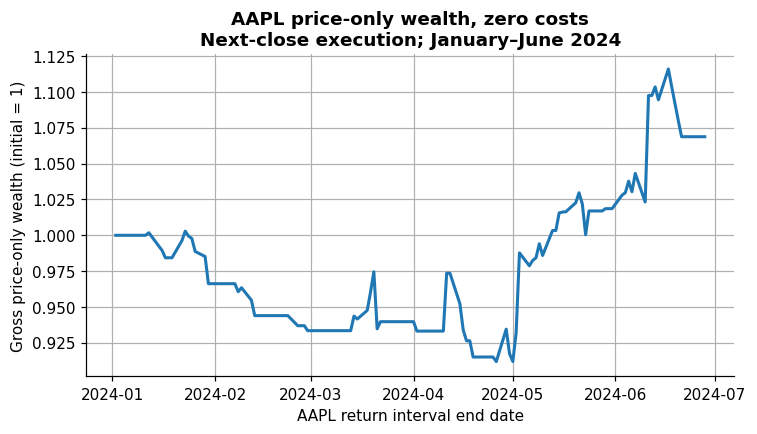

**Figure.** A line displays gross wealth compounded from one across the fixed AAPL sample under the lagged long-or-cash rule.

In [25]:
# Purpose: How does a sequence of returns become wealth — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_wealth_summary = pd.Series(
    {
        "return rows compounded": len(aapl_ledger),
        "initial gross wealth": 1.0,
        "minimum one-period gross factor": float((1 + aapl_ledger["strategy_return_gross"]).min()),
        "gross terminal wealth": float(aapl_ledger["strategy_wealth_gross"].iloc[-1]),
    },
    name="Observed value",
)
display(real_wealth_summary.to_frame().round(6))
figure, axis = plt.subplots()
axis.plot(aapl_ledger.index, aapl_ledger["strategy_wealth_gross"], linewidth=2)
axis.set_title("AAPL price-only wealth, zero costs\nNext-close execution; January–June 2024")
axis.set_xlabel("AAPL return interval end date")
axis.set_ylabel("Gross price-only wealth (initial = 1)")
show_figure_with_alt_text(figure, "A line displays gross wealth compounded from one across the fixed AAPL sample under the lagged long-or-cash rule.")
assert (1 + aapl_ledger["strategy_return_gross"]).gt(0).all()

### Interpret Code 2

Across 124 stored AAPL rows, the first row is an initial wealth marker and the other 123 rows define price intervals. The minimum strategy gross factor is 0.959143 and the terminal gross price-only wealth is 1.068799 from 1. The figure plots that same recurrence over January 2–June 28, 2024. This does not include dividends, transaction costs or evidence of real fills.

### Discussion questions

1. Starting from wealth 1, compound returns `10%, -10%`. Calculate terminal wealth and compare it with 1 plus the arithmetic sum of returns. Explain why the two values differ.
2. A student calculates cumulative strategy return with `strategy_return.cumsum()`. Identify a path on which this disagrees with compounding, calculate both endpoints, and state the recurrence that the wealth ledger must satisfy.

## Issue 13 — Which accounting identities must the ledger satisfy?


A backtest audit should verify identities row by row rather than inspect only the final number. Positions must equal signals from two rows earlier under the stated rule. Trades must equal position changes. Gross strategy returns must equal position times same-interval asset returns. Wealth must follow the recursive update and equal direct compounding.

These checks identify the first broken transformation. A passing identity confirms internal consistency with the written artificial assumptions; it does not establish that the assumptions are realistic or the strategy is valuable.

The output below reports both Boolean results and the largest numerical residual.


### Connection to a documented source

The source-grounded AAPL ledger checks timing and accounting identities row by row. Software assertions can detect a contradiction between stored columns, but they cannot verify Yahoo Finance's upstream field construction or an assumed execution price.

Sources: [NumPy numerical-comparison documentation](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html); [pandas testing documentation](https://pandas.pydata.org/docs/reference/api/pandas.testing.assert_series_equal.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which artificial accounting residuals must equal zero.

In [26]:
# Purpose: Which accounting identities must the ledger satisfy — controlled example.
previous_signal = bt["signal_at_close"].shift(2)
position_residual = bt.loc[previous_signal.notna(), "position"] - previous_signal.dropna()
trade_residual = bt["signed_trade"] - (bt["position"] - bt["position"].shift(1).fillna(0.0))
return_residual = bt.loc[bt["asset_return"].notna(), "strategy_return_gross"] - (
    bt.loc[bt["asset_return"].notna(), "position"] * bt.loc[bt["asset_return"].notna(), "asset_return"]
)
recursive_wealth = bt["strategy_wealth_gross"].shift(1).fillna(1.0) * (1 + bt["strategy_return_gross"])
wealth_residual = bt["strategy_wealth_gross"] - recursive_wealth

ledger_checks = pd.DataFrame(
    [
        ("Position equals signal from two rows earlier", np.allclose(position_residual, 0), float(np.max(np.abs(position_residual))) if len(position_residual) else 0.0),
        ("Signed trade equals position change", np.allclose(trade_residual, 0), float(np.max(np.abs(trade_residual)))),
        ("Gross return equals position × asset return", np.allclose(return_residual, 0), float(np.max(np.abs(return_residual)))),
        ("Wealth follows recursive update", np.allclose(wealth_residual, 0), float(np.max(np.abs(wealth_residual)))),
        ("Terminal wealth equals direct product", np.isclose(bt["strategy_wealth_gross"].iloc[-1], np.prod(1 + bt["strategy_return_gross"])), float(abs(bt["strategy_wealth_gross"].iloc[-1] - np.prod(1 + bt["strategy_return_gross"])))),
    ],
    columns=["Identity", "Passed", "Maximum absolute residual"],
)
display(ledger_checks.style.format({"Maximum absolute residual": "{:.3e}"}).hide(axis="index").set_caption("Row-level Week 4 accounting checks"))
assert ledger_checks["Passed"].all()

Identity,Passed,Maximum absolute residual
Position equals signal from two rows earlier,True,0.000e+00
Signed trade equals position change,True,0.000e+00
Gross return equals position × asset return,True,0.000e+00
Wealth follows recursive update,True,0.000e+00
Terminal wealth equals direct product,True,0.000e+00


### Interpret Code 1


All five checks pass with zero or numerical-rounding residuals. The five displayed maximum absolute residuals are all 0 (up to floating-point precision). If same-row signal were substituted for position, the timing identity would fail. The return multiplication identity could still pass if it multiplied the invalid position by the asset return, which shows why multiple independent checks are necessary.

An audit is not a search for a preferred result. Failed checks must be preserved and repaired before any wealth comparison is interpreted.

### Source-grounded example

Code 2 recomputes the AAPL signal lag, trades, gross returns, and wealth recursion and reports the largest absolute residual for each identity.

### Before Code 2

Predict the largest AAPL residual for lag, trade, return, and wealth identities.

In [27]:
# Purpose: Which accounting identities must the ledger satisfy — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
available_lag_rows = aapl_ledger["signal_after_close"].shift(2).notna()
lag_residual_real = aapl_ledger.loc[available_lag_rows, "position"] - aapl_ledger["signal_after_close"].shift(2).loc[available_lag_rows]
trade_residual_real = aapl_ledger["signed_trade"] - (aapl_ledger["position"] - aapl_ledger["position"].shift(1).fillna(0.0))
return_residual_real = aapl_ledger["strategy_return_gross"] - calculate_gross_return(aapl_ledger["position"], aapl_ledger["asset_return"])
prior_wealth = aapl_ledger["strategy_wealth_gross"].shift(1).fillna(1.0)
wealth_residual_real = aapl_ledger["strategy_wealth_gross"] - prior_wealth * (1 + aapl_ledger["strategy_return_gross"])
real_identity_check = pd.Series(
    {"largest lag residual": lag_residual_real.abs().max(), "largest trade residual": trade_residual_real.abs().max(), "largest return residual": return_residual_real.abs().max(), "largest wealth residual": wealth_residual_real.abs().max()},
    name="Largest absolute residual",
)
display(real_identity_check.to_frame())
assert np.allclose(real_identity_check, 0.0)

,Largest absolute residual
largest lag residual,0.0
largest trade residual,0.0
largest return residual,0.0
largest wealth residual,0.0


### Interpret Code 2


The largest absolute residual is 0 for all four AAPL identities: two-rows-earlier signal to position, adjacent positions to signed trade, position times asset return to gross strategy return, and prior wealth times the current gross factor to current wealth. These checks establish internal consistency among stored columns. They do not verify upstream provider fields or real execution.

### Discussion questions

1. A ledger ends at the expected wealth but contains one trade that does not equal the change in adjacent positions. Decide whether matching terminal wealth is sufficient, identify the failed row-level identity, and explain which later cost calculation would be corrupted.
2. The maximum return residual is zero, but the position was formed from the same-row signal. Explain why the return identity can pass while the timing identity fails, and name both checks required before accepting the ledger.

## Issue 14 — Why is a same-period signal return invalid?


A same-period implementation multiplies a signal formed after row $t$ closes by the asset return that ended at that close. The return existed before the signal. This is look-ahead bias even if the signal formula uses only trailing prices, because return attribution occurs across the wrong boundary.

The invalid calculation is $\widetilde r_{p,t}=s_t r_{a,t}$. Under the stated timing, the valid calculation is

$$
r^{\mathrm{gross}}_{p,t}=p_t r_{a,t}=s_{t-2}r_{a,t}.
$$

The tilde marks only the deliberately invalid classroom calculation; it is not a new performance metric.

The comparison below keeps the signal rule and artificial price path fixed. Only the alignment changes. A different final wealth proves that alignment matters; it does not prove that the invalid result is always larger.

A one-row shift is also too early for the main next-close design: it assumes entry at the same close used to calculate the signal afterward. Both zero-lag and one-lag candidates must be rejected here.

The first differing row is more informative than the endpoint because it identifies the exact impossible return assignment.


### Connection to a documented source

The same AAPL signals are deliberately aligned in two ways. The same-row version uses a signal after the close to earn a return ending at that close and is therefore invalid, regardless of whether its terminal wealth is higher or lower.

Sources: [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html); [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the first artificial row on which valid and same-period implementations differ.

,asset_return,signal_at_close,position,strategy_return_gross,invalid_same_period_return,return_difference
Date,,,,,,
2026-03-05 00:00:00,-0.40%,nan,0.000000,0.00%,0.00%,0.00%
2026-03-06 00:00:00,0.60%,nan,0.000000,0.00%,0.00%,0.00%
2026-03-09 00:00:00,0.30%,1.000000,0.000000,0.00%,0.30%,0.30%
2026-03-10 00:00:00,-1.20%,1.000000,0.000000,0.00%,-1.20%,-1.20%
2026-03-11 00:00:00,-0.80%,0.000000,1.000000,-0.80%,0.00%,0.80%


,Value
first_different_date,2026-03-09 00:00:00
different_rows,14
valid_terminal_wealth,0.966254
invalid_terminal_wealth,1.004543


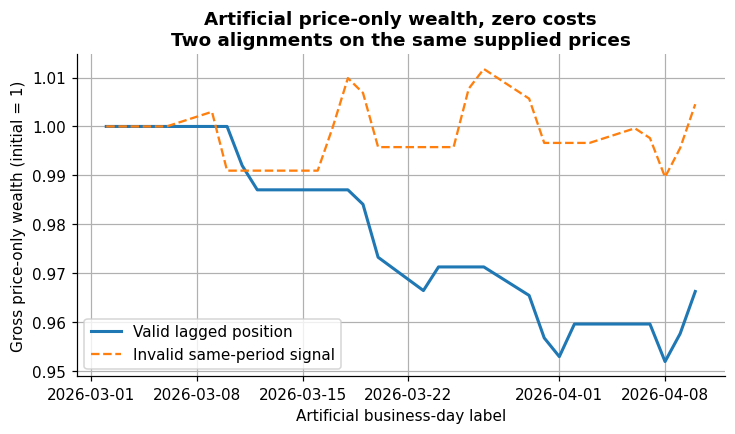

**Figure.** Two artificial gross-wealth lines compare a valid lagged position with an invalid same-period signal; the lines diverge after the first available signal.

In [28]:
# Purpose: Why is a same-period signal return invalid — controlled example.
bt["invalid_same_period_return"] = calculate_gross_return(bt["signal_at_close"].fillna(0.0), bt["asset_return"])
bt["invalid_same_period_wealth"] = (1 + bt["invalid_same_period_return"]).cumprod()
bt["return_difference"] = bt["invalid_same_period_return"] - bt["strategy_return_gross"]

difference_rows = bt.index[~np.isclose(bt["return_difference"], 0.0)]
first_difference = difference_rows[0]
first_difference_position = bt.index.get_loc(first_difference)
alignment_preview = bt.iloc[
    max(0, first_difference_position - 2) : first_difference_position + 3
][["asset_return", "signal_at_close", "position", "strategy_return_gross", "invalid_same_period_return", "return_difference"]]
display(alignment_preview.style.format({k: "{:.2%}" for k in ["asset_return", "strategy_return_gross", "invalid_same_period_return", "return_difference"]}).set_caption("First valid-versus-invalid return difference"))

alignment_summary = pd.Series(
    {
        "first_different_date": first_difference,
        "different_rows": int(len(difference_rows)),
        "valid_terminal_wealth": bt["strategy_wealth_gross"].iloc[-1],
        "invalid_terminal_wealth": bt["invalid_same_period_wealth"].iloc[-1],
    },
    name="Value",
)
display(alignment_summary.to_frame())

figure, axis = plt.subplots()
axis.plot(bt.index, bt["strategy_wealth_gross"], label="Valid lagged position", linewidth=2)
axis.plot(bt.index, bt["invalid_same_period_wealth"], label="Invalid same-period signal", linestyle="--")
axis.set_title("Artificial price-only wealth, zero costs\nTwo alignments on the same supplied prices")
axis.set_xlabel("Artificial business-day label")
axis.set_ylabel("Gross price-only wealth (initial = 1)")
axis.legend()
show_figure_with_alt_text(figure, "Two artificial gross-wealth lines compare a valid lagged position with an invalid same-period signal; the lines diverge after the first available signal.")

assert len(difference_rows) > 0
assert not np.isclose(alignment_summary["valid_terminal_wealth"], alignment_summary["invalid_terminal_wealth"])

### Interpret Code 1

The artificial zero-lag and two-lag returns first differ on March 9, 2026; 14 rows have different returns. The plotted valid next-close calculation ends at 0.966254, while the deliberately invalid same-period calculation ends at 1.004543. The reason to reject the latter is its use of a signal after the attributed interval ended, not its larger endpoint.

### Source-grounded example

Code 2 uses the same AAPL signal and return rows to compare the valid lagged position with an invalid same-row position. This is a timing audit, not a method ranking.

### Before Code 2

Predict the first AAPL return assigned differently and whether the two gross wealth endpoints are equal.

In [29]:
# Purpose: Why is a same-period signal return invalid — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
invalid_position = aapl_ledger["signal_after_close"].fillna(0.0)
invalid_return = calculate_gross_return(invalid_position, aapl_ledger["asset_return"])
invalid_wealth = (1 + invalid_return).cumprod()
different_rows = aapl_ledger["position"].ne(invalid_position)
first_difference = aapl_ledger.index[different_rows][0]
real_timing_comparison = pd.Series(
    {
        "first differing date": str(first_difference.date()),
        "valid position": float(aapl_ledger.loc[first_difference, "position"]),
        "invalid same-row position": float(invalid_position.loc[first_difference]),
        "asset return on first difference (%)": 100 * float(aapl_ledger.loc[first_difference, "asset_return"]),
        "valid gross terminal wealth": float(aapl_ledger["strategy_wealth_gross"].iloc[-1]),
        "invalid gross terminal wealth": float(invalid_wealth.iloc[-1]),
    },
    name="Observed value",
)
display(real_timing_comparison.to_frame().round(6))
assert different_rows.any()
one_lag_position = aapl_ledger["signal_after_close"].shift(1).fillna(0.0)
one_lag_return = calculate_gross_return(one_lag_position, aapl_ledger["asset_return"])
alignment_check = pd.DataFrame({
    "Signal lag (rows)": [0, 1, 2],
    "Timing matches next-close rule": [False, False, True],
    "Gross price-only terminal wealth (initial=1)": [
        (1 + invalid_return).prod(),
        (1 + one_lag_return).prod(),
        aapl_ledger["strategy_wealth_gross"].iloc[-1],
    ],
})
display(alignment_check.style.hide(axis="index").format({"Gross price-only terminal wealth (initial=1)": "{:.6f}"}).set_caption("AAPL 2024-01-02–2024-06-28: only the alignment changes; costs zero"))
assert not np.array_equal(one_lag_position, aapl_ledger["position"])

,Observed value
first differing date,2024-01-10
valid position,0.0
invalid same-row position,1.0
asset return on first difference (%),0.56714
valid gross terminal wealth,1.068799
invalid gross terminal wealth,1.51796


Signal lag (rows),Timing matches next-close rule,Gross price-only terminal wealth (initial=1)
0,False,1.517960
1,False,0.993516
2,True,1.068799


### Interpret Code 2

The AAPL zero-lag version first differs on January 10, 2024: it incorrectly uses signal 1 to earn that day's 0.567140% price return. The endpoint table gives 1.517960 for zero lag, 0.993516 for one lag and 1.068799 for the required two lag, all from initial wealth 1. Only the two-lag version matches the stated next-close execution. Neither an attractive endpoint nor a smaller endpoint repairs a timing violation.

### Discussion questions

1. A same-period implementation has lower terminal wealth than the valid lagged implementation. Decide whether the lower result makes it acceptable. Identify the unavailable signal event and the earliest interval the signal may control.
2. Design a prefix test for a backtest: choose a cutoff date, state which earlier positions and returns must remain unchanged after later rows are appended, and explain what a changed historical value reveals.

## Issue 15 — How should a missing asset return be handled?


A missing asset return can arise from a missing price, an unmatched interval, a market closure, or an incomplete source. It must not be silently replaced with zero while a nonzero position is held, because zero asserts that the asset value did not change over the intended interval.

The policy below distinguishes two cases. If the strategy is in cash, a missing asset return does not affect that interval's specified zero cash return. If the strategy is exposed, the gross strategy return remains unresolved and the ledger stops before compounding through it.

This rule preserves the difference between no asset observation and an observed zero return.


### Connection to a documented source

The AAPL response naturally has no Close-to-Close return on its first requested row. The example also creates one clearly labeled teaching modification by removing a later return so students can compare stopping, excluding the interval, and inventing a zero return without confusing modified data with the source response.

Sources: [pandas missing-value documentation](https://pandas.pydata.org/docs/user_guide/missing_data.html); [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which missing-return policies preserve or change the observed sample.

In [30]:
# Purpose: How should a missing asset return be handled — controlled example.
missing_demo = pd.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, 0.0],
        "asset_return": [np.nan, np.nan, 0.02, -0.01],
    },
    index=pd.Index(["Cash and missing", "Long and missing", "Long and observed", "Cash and observed"], name="Case"),
)
missing_demo["strategy_return_under_policy"] = np.where(
    missing_demo["position"].eq(0.0),
    0.0,
    missing_demo["asset_return"],
)
missing_demo["status"] = np.where(
    missing_demo["strategy_return_under_policy"].isna(),
    "Stop: exposed return unresolved",
    "Resolved under stated rule",
)
display(missing_demo.style.format({"asset_return": "{:.2%}", "strategy_return_under_policy": "{:.2%}"}).set_caption("Missing-return policy depends on exposure"))

assert missing_demo.loc["Cash and missing", "strategy_return_under_policy"] == 0.0
assert pd.isna(missing_demo.loc["Long and missing", "strategy_return_under_policy"])
assert missing_demo.loc["Long and observed", "strategy_return_under_policy"] == 0.02

,position,asset_return,strategy_return_under_policy,status
Case,,,,
Cash and missing,0.000000,nan%,0.00%,Resolved under stated rule
Long and missing,1.000000,nan%,nan%,Stop: exposed return unresolved
Long and observed,1.000000,2.00%,2.00%,Resolved under stated rule
Cash and observed,0.000000,-1.00%,0.00%,Resolved under stated rule


### Interpret Code 1


The missing return is resolved as zero only when the specified portfolio is in zero-return cash. The long-and-missing case remains unresolved because the held asset's interval return is unknown. Compounding must stop or the source interval must be repaired.

Forward filling invents an unchanged price for the missing observation and shifts the observed change to a later row. Dropping the missing price can instead create a longer interval. Neither recovers the original daily holding return.

### Source-grounded example

Code 2 first records the naturally unavailable AAPL return on the initial requested row. It then makes one explicitly labeled teaching modification by removing a later observed return while the strategy is long.

### Before Code 2

Predict the naturally unavailable first AAPL return and the effect of a deliberately removed later return.

In [31]:
# Purpose: How should a missing asset return be handled — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
modified_ledger = aapl_ledger.copy()
removed_date = modified_ledger.index[modified_ledger["position"].eq(1.0) & modified_ledger["asset_return"].notna()][3]
original_return = float(modified_ledger.loc[removed_date, "asset_return"])
modified_ledger.loc[removed_date, "asset_return"] = np.nan
modified_ledger.loc[removed_date:, ["strategy_return_gross", "strategy_wealth_gross"]] = np.nan
real_missing_case = pd.DataFrame(
    [
        ("First returned row", str(aapl_ledger.index[0].date()), aapl_ledger["position"].iloc[0], aapl_ledger["asset_return"].iloc[0], "No preceding requested Close"),
        ("Teaching modification: one removed return", str(removed_date.date()), modified_ledger.loc[removed_date, "position"], modified_ledger.loc[removed_date, "asset_return"], f"Original observed return was {original_return:.4%}"),
    ],
    columns=["Evidence type", "Date", "Position", "Displayed asset return", "Reason"],
)
display(real_missing_case.style.hide(axis="index").format({"Displayed asset return": "{:.4%}"}).set_caption("First returned row and a deliberately removed later return"))
assert pd.isna(aapl_ledger["asset_return"].iloc[0]) and pd.isna(modified_ledger.loc[removed_date, "asset_return"])
try:
    calculate_gross_return(modified_ledger["position"], modified_ledger["asset_return"])
except ValueError as error:
    missing_response = str(error)
else:
    raise AssertionError("The exposed missing return was not rejected.")
display(pd.DataFrame([{
    "Modified date": str(removed_date.date()),
    "Position (fraction)": modified_ledger.loc[removed_date, "position"],
    "Calculation result": missing_response,
    "Later wealth reported?": "No",
}]).style.hide(axis="index").set_caption("Artificial removal from AAPL data: the main calculation must stop"))
assert missing_response == "Stop: an exposed return is missing or nonfinite."

Evidence type,Date,Position,Displayed asset return,Reason
First returned row,2024-01-02,0.000000,nan%,No preceding requested Close
Teaching modification: one removed return,2024-01-22,1.000000,nan%,Original observed return was 1.2163%


Modified date,Position (fraction),Calculation result,Later wealth reported?
2024-01-22,1.000000,Stop: an exposed return is missing or nonfinite.,No


### Interpret Code 2

The first AAPL row, January 2, 2024, has no preceding requested Close and has cash position 0. In the explicitly modified example, the observed 1.2163% return ending January 22 is removed while position is 1. The main calculation then reports 'Stop: an exposed return is missing or nonfinite.' No later wealth is reported for that modified calculation. The original source-derived ledger remains unchanged.

### Discussion questions

1. A return is missing while the strategy is long. Compare filling zero, dropping the interval, and stopping the backtest. State the financial claim each choice makes and select the only action that does not invent an observed holding return without additional evidence.
2. The first price row has no preceding price, and its initial position is cash. Explain why assigning strategy return zero is consistent there, then state why the same treatment is not automatically valid for a missing return during a later long position.

## Issue 16 — What does the final row mean, and is liquidation required?


The final row closes the observed return interval but may leave a nonzero position. Here the reported position is the exposure held through that interval, before any additional final-close transaction. Signals on the final two rows cannot yet have contributed a full evaluated holding interval. Reporting that position and forcing a sale are different terminal conventions. A forced liquidation creates an additional trade at a boundary for which a price, execution rule, and later cost treatment must be stated.

Week 4 reports the position held during the final observed return and does not append a liquidation. This avoids inventing an execution outside the displayed sample. If an assignment requires terminal cash, add a separately dated trade. The comparison below hypothesizes a prearranged sale at the same final marking price, with zero costs and no additional holding interval. Liquidating later at an unknown price would not guarantee unchanged wealth.

Comparisons must use the same terminal convention because trade counts and later costs can change even when gross wealth through the final observed return does not.


### Connection to a documented source

The final AAPL row identifies an observed position and wealth boundary. Appending liquidation would require an additional execution event. The SEC's order guidance helps establish that an order does not guarantee a particular price, so this lesson records only the accounting consequence of the chosen terminal rule.

Sources: [SEC trade-execution guidance](https://www.sec.gov/investor/pubs/tradexec.htm); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the extra terminal trade under a forced-liquidation convention.

In [32]:
# Purpose: What does the final row mean, and is liquidation required — controlled example.
terminal_position = float(bt["position"].iloc[-1])
observed_changes = int((bt["absolute_trade"] > 0).sum())

terminal_comparison = pd.DataFrame(
    [
        {
            "Convention": "Report position for final interval",
            "Final reported position": terminal_position,
            "Additional terminal trade": 0.0,
            "Total position changes": observed_changes,
            "Gross wealth through last observed return": bt["strategy_wealth_gross"].iloc[-1],
        },
        {
            "Convention": "Hypothetical liquidation at final mark",
            "Final reported position": 0.0,
            "Additional terminal trade": abs(0.0 - terminal_position),
            "Total position changes": observed_changes + int(terminal_position != 0.0),
            "Gross wealth through last observed return": bt["strategy_wealth_gross"].iloc[-1],
        },
    ]
)
display(terminal_comparison.style.format({"Gross wealth through last observed return": "{:.6f}"}).hide(axis="index").set_caption("Two terminal-boundary conventions"))

assert terminal_comparison["Gross wealth through last observed return"].nunique() == 1
assert terminal_comparison.loc[1, "Additional terminal trade"] == abs(terminal_position)

Convention,Final reported position,Additional terminal trade,Total position changes,Gross wealth through last observed return
Report position for final interval,1.000000,0.000000,7,0.966254
Hypothetical liquidation at final mark,0.000000,1.000000,8,0.966254


### Interpret Code 1

The artificial ledger finishes long, with seven exposure changes and gross wealth 0.966254. The hypothetical sale at the same final mark adds one full exit, making eight changes, without changing gross wealth under zero costs. That equality depends on the stipulated sale price; a sale later at a different price need not preserve it.

### Source-grounded example

Code 2 compares reporting the final AAPL position with a hypothetical prearranged liquidation at the same final mark. Both conventions stop at the same last observed return; only the second adds a position change.

### Before Code 2

Predict the final AAPL position and the extra position change required if liquidation is appended.

In [33]:
# Purpose: What does the final row mean, and is liquidation required — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
final_position_real = float(aapl_ledger["position"].iloc[-1])
observed_changes_real = float(aapl_ledger["absolute_trade"].sum())
real_terminal = pd.DataFrame(
    [
        ("Report observed final position", final_position_real, 0.0, observed_changes_real, aapl_ledger["strategy_wealth_gross"].iloc[-1]),
        ("Hypothetical liquidation at final mark", 0.0, abs(final_position_real), observed_changes_real + abs(final_position_real), aapl_ledger["strategy_wealth_gross"].iloc[-1]),
    ],
    columns=["Terminal convention", "Reported final position", "Additional position change", "Total absolute position change", "Gross wealth through last observed return"],
)
display(real_terminal.style.hide(axis="index").format({"Gross wealth through last observed return": "{:.6f}"}).set_caption("AAPL terminal-boundary conventions before execution costs"))
assert real_terminal["Gross wealth through last observed return"].nunique() == 1

Terminal convention,Reported final position,Additional position change,Total absolute position change,Gross wealth through last observed return
Report observed final position,0.000000,0.000000,30.000000,1.068799
Hypothetical liquidation at final mark,0.000000,0.000000,30.000000,1.068799


### Interpret Code 2

AAPL ends June 28, 2024 in cash under the two-lag convention, with 30 exposure changes and normalized gross wealth 1.068799. Therefore the hypothetical final liquidation adds zero changes, and both table rows retain the same wealth. This differs from the artificial example, which ends long. A recent signal of 1 does not imply exposure during the final evaluated interval.

### Discussion questions

1. Two strategies end with equal gross wealth, but one is long and one is cash. If the comparison requires terminal cash, identify the extra event for the long strategy and explain why cost and execution evidence become necessary.
2. A team appends a zero-return liquidation row and counts one trade but gives no timestamp or execution price. State what the row records as an accounting convention and which real-market claims remain unsupported.

## Issue 17 — What does a gross buy-and-hold benchmark add?


A buy-and-hold benchmark keeps position 1 after the stated initial boundary and compounds the same asset returns. It answers what continuous exposure to the same artificial price path would have produced before costs. It does not validate the strategy, identify a risk-adjusted winner, or establish statistical significance.

The strategy and benchmark must use the same return rows and gross convention. Their initial positions may differ by design, so the starting boundary must be stated.

Week 6 adds costs to compatible benchmarks. Week 7 adds risk and uncertainty measures; weighting choices belong to Week 8.


### Connection to a documented source

The AAPL strategy and buy-and-hold benchmark use the same requested Close-to-Close return rows and the same gross convention. The comparison isolates exposure rules on one historical sample; it does not establish superiority, statistical significance, or future performance.

Sources: [pandas cumulative-product documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.cumprod.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict whether the two artificial wealth endpoints must match.

Method,Return rows,Long intervals,Position changes,Gross terminal wealth
Week 4 lagged long-or-cash rule,30,13,7,0.966254
Artificial buy and hold,30,29,1,1.042053


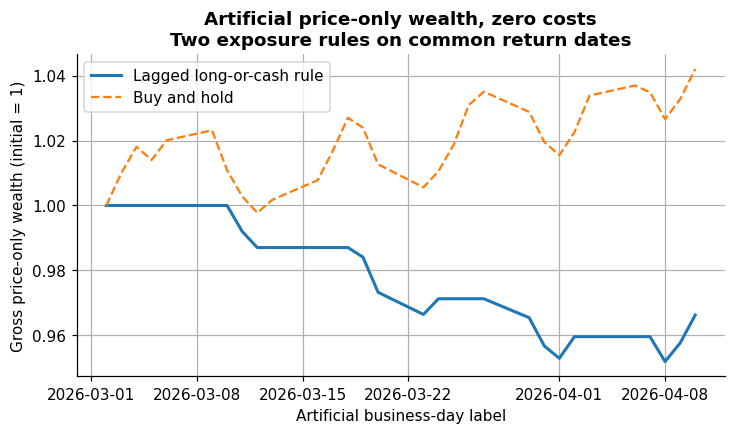

**Figure.** Two artificial gross wealth lines compare the lagged long-or-cash rule with continuous buy-and-hold exposure on the same return dates.

In [34]:
# Purpose: What does a gross buy-and-hold benchmark add — controlled example.
benchmark_position = pd.Series(1.0, index=bt.index)
benchmark_position.iloc[0] = 0.0
bt["buy_hold_return_gross"] = calculate_gross_return(benchmark_position, bt["asset_return"])
bt["buy_hold_wealth_gross"] = (1 + bt["buy_hold_return_gross"]).cumprod()

benchmark_summary = pd.DataFrame(
    [
        {
            "Method": "Week 4 lagged long-or-cash rule",
            "Return rows": len(bt),
            "Long intervals": int(bt["position"].sum()),
            "Position changes": int((bt["absolute_trade"] > 0).sum()),
            "Gross terminal wealth": bt["strategy_wealth_gross"].iloc[-1],
        },
        {
            "Method": "Artificial buy and hold",
            "Return rows": len(bt),
            "Long intervals": int(bt["asset_return"].notna().sum()),
            "Position changes": 1,
            "Gross terminal wealth": bt["buy_hold_wealth_gross"].iloc[-1],
        },
    ]
)
display(benchmark_summary.style.format({"Gross terminal wealth": "{:.6f}"}).hide(axis="index").set_caption("Gross comparison on common artificial asset-return rows"))

figure, axis = plt.subplots()
axis.plot(bt.index, bt["strategy_wealth_gross"], label="Lagged long-or-cash rule", linewidth=2)
axis.plot(bt.index, bt["buy_hold_wealth_gross"], label="Buy and hold", linestyle="--")
axis.set_title("Artificial price-only wealth, zero costs\nTwo exposure rules on common return dates")
axis.set_xlabel("Artificial business-day label")
axis.set_ylabel("Gross price-only wealth (initial = 1)")
axis.legend()
show_figure_with_alt_text(figure, "Two artificial gross wealth lines compare the lagged long-or-cash rule with continuous buy-and-hold exposure on the same return dates.")

assert benchmark_summary["Return rows"].nunique() == 1
assert np.isclose(bt["buy_hold_wealth_gross"].iloc[-1], bt["Close"].iloc[-1] / bt["Close"].iloc[0])

### Interpret Code 1

The shared artificial strategy has 13 long intervals, seven position changes and terminal gross wealth 0.966254. Buy and hold has 29 price intervals, one entry and terminal wealth 1.042053. The two plotted paths use the same 30 price labels, including an initial wealth marker. Different exposure rules explain different accounting results; the example is not a sample of real investment performance.

### Source-grounded example

Code 2 compares the AAPL lagged long-or-cash rule with continuous buy-and-hold exposure on identical Close-to-Close rows and before transaction costs.

### Before Code 2

Predict whether equal date counts force equal terminal wealth when exposure rules differ.

Exposure rule,Stored rows,Long intervals,Position-change rows,Gross terminal wealth
Lagged long-or-cash rule,124,63,30,1.068799
Buy and hold,124,123,1,1.134561


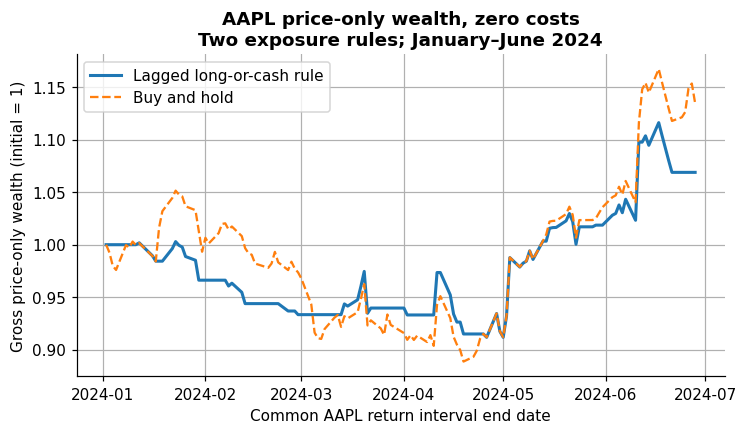

**Figure.** Two lines compare gross wealth for the lagged AAPL long-or-cash rule and AAPL buy and hold on the same requested return rows.

In [35]:
# Purpose: What does a gross buy-and-hold benchmark add — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_benchmark = pd.DataFrame(
    [
        ("Lagged long-or-cash rule", len(aapl_ledger), int(aapl_ledger["position"].eq(1.0).sum()), int(aapl_ledger["absolute_trade"].gt(0).sum()), aapl_ledger["strategy_wealth_gross"].iloc[-1]),
        ("Buy and hold", len(aapl_ledger), int(aapl_ledger["asset_return"].notna().sum()), 1, aapl_ledger["buy_hold_wealth_gross"].iloc[-1]),
    ],
    columns=["Exposure rule", "Stored rows", "Long intervals", "Position-change rows", "Gross terminal wealth"],
)
display(real_benchmark.style.hide(axis="index").format({"Gross terminal wealth": "{:.6f}"}).set_caption("Gross AAPL comparison on common return rows"))
figure, axis = plt.subplots()
axis.plot(aapl_ledger.index, aapl_ledger["strategy_wealth_gross"], label="Lagged long-or-cash rule", linewidth=2)
axis.plot(aapl_ledger.index, aapl_ledger["buy_hold_wealth_gross"], label="Buy and hold", linestyle="--")
axis.set_title("AAPL price-only wealth, zero costs\nTwo exposure rules; January–June 2024")
axis.set_xlabel("Common AAPL return interval end date")
axis.set_ylabel("Gross price-only wealth (initial = 1)")
axis.legend()
show_figure_with_alt_text(figure, "Two lines compare gross wealth for the lagged AAPL long-or-cash rule and AAPL buy and hold on the same requested return rows.")
assert real_benchmark["Stored rows"].nunique() == 1

### Interpret Code 2

Both AAPL methods use 124 price dates and 123 price intervals. The strategy holds exposure for 63 intervals, records 30 changes and ends at gross price-only wealth 1.068799. Buy and hold is exposed for all 123 intervals, records one initial entry and ends at 1.134561. The figure shows these same endpoints. Only the exposure rule changes; dividend-inclusive returns, costs, risk and uncertainty are not evaluated.

### Discussion questions

1. Buy and hold has higher gross price-only wealth on the displayed AAPL sample. Calculate the difference in terminal normalized wealth, then name the cost, risk and uncertainty evidence still needed before recommending either exposure rule.
2. A benchmark starts one return date later than the strategy. Identify why endpoint wealth is no longer based on common intervals and specify the exact date intersection and initialization rule needed to rebuild the comparison.

## Issue 18 — Can ending weights be used to account for the return just earned?


Week 2 derived the weighted-return identity. Here we apply it to a backtest accounting error: using ending weights to explain the interval that produced those weights. A backtest may hold more than one asset. Given beginning-of-interval asset values or weights, portfolio return is the value-weighted sum of same-interval asset returns. The asset labels, beginning boundary, ending boundary, and return convention must match.

For assets $i=1,\ldots,N$, beginning weights $w_{i,t-1}$, and decimal asset returns $r_{i,t}$ over one common interval, the gross portfolio return $r^{\mathrm{gross}}_{p,t}$ is

$$
r^{\mathrm{gross}}_{p,t}=\sum_{i=1}^{N} w_{i,t-1}r_{i,t},
\qquad
\sum_{i=1}^{N}w_{i,t-1}=1.
$$

The weights are dimensionless shares of beginning portfolio value. The holdings example reports values in US dollars and does not estimate or optimize the weights.

This issue uses stated artificial holdings rather than selecting weights. Weight selection begins in Week 8. The two positions are held without rebalancing during one interval, so their ending values determine both portfolio return and weight drift.

If the portfolio has no flows or rebalancing during the interval, write $h_{i,t}$ for ending weights before any new trade. They satisfy
$$
h_{i,t}=\frac{w_{i,t-1}(1+r_{i,t})}{1+r^{\mathrm{gross}}_{p,t}}.
$$
They already depend on the realized returns. Substituting them into the beginning-weight formula changes the accounting question. Compare the two sums numerically below; do not choose the larger one.

No trade or cost is attached because the beginning holdings are treated as given.


### Connection to a documented source

The AAPL and MSFT requests supply same-date price changes. Beginning values of 70 US dollars and 30 US dollars are instructor-specified holdings, not provider facts or recommended weights. Their weighted return is valid only on the common interval.

Sources: [pandas fractional-change documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html); [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict the artificial portfolio return, ending value, and ending weights.

In [36]:
# Purpose: Can ending weights be used to account for the return just earned — controlled example.
holdings_case = pd.DataFrame(
    {
        "Beginning value": [70.0, 30.0],
        "Same-interval asset return": [0.02, -0.01],
    },
    index=pd.Index(["Artificial Asset A", "Artificial Asset B"], name="Asset"),
)
holdings_case["Beginning weight"] = holdings_case["Beginning value"] / holdings_case["Beginning value"].sum()
holdings_case["Return contribution"] = holdings_case["Beginning weight"] * holdings_case["Same-interval asset return"]
holdings_case["Ending value"] = holdings_case["Beginning value"] * (1 + holdings_case["Same-interval asset return"])
holdings_case["Ending weight"] = holdings_case["Ending value"] / holdings_case["Ending value"].sum()
portfolio_return_one_interval = holdings_case["Return contribution"].sum()
portfolio_return_from_values = holdings_case["Ending value"].sum() / holdings_case["Beginning value"].sum() - 1

display(holdings_case.style.format({
    "Beginning weight": "{:.2%}",
    "Same-interval asset return": "{:.2%}",
    "Return contribution": "{:.2%}",
    "Ending weight": "{:.2%}",
}).set_caption("Specified artificial holdings over one common interval"))
display(pd.Series({"Portfolio return from contributions": portfolio_return_one_interval, "Portfolio return from total values": portfolio_return_from_values, "Ending total value": holdings_case["Ending value"].sum()}, name="Value").to_frame())

assert np.isclose(portfolio_return_one_interval, 0.7 * 0.02 + 0.3 * -0.01)
assert np.isclose(portfolio_return_one_interval, portfolio_return_from_values)
assert np.isclose(holdings_case["Ending weight"].sum(), 1.0)
ending_weight_return = (holdings_case["Ending weight"] * holdings_case["Same-interval asset return"]).sum()
display(pd.DataFrame({
    "Weight timing": ["Beginning: correct accounting", "Ending: wrong for this interval"],
    "Return (decimal)": [portfolio_return_one_interval, ending_weight_return],
}).style.hide(axis="index").format({"Return (decimal)": "{:.8f}"}).set_caption("Artificial one-interval return: same holdings and asset returns; only weight timing changes"))
assert not np.isclose(ending_weight_return, portfolio_return_one_interval)

,Beginning value,Same-interval asset return,Beginning weight,Return contribution,Ending value,Ending weight
Asset,,,,,,
Artificial Asset A,70.000000,2.00%,70.00%,1.40%,71.400000,70.62%
Artificial Asset B,30.000000,-1.00%,30.00%,-0.30%,29.700000,29.38%


,Value
Portfolio return from contributions,0.011
Portfolio return from total values,0.011
Ending total value,101.100


Weight timing,Return (decimal)
Beginning: correct accounting,0.01100000
Ending: wrong for this interval,0.01118694


### Interpret Code 1


The beginning-weight return is 1.1%, and total value rises from 100 to 101.1 currency units. Using ending weights instead produces approximately 1.118694%, which cannot reconcile the actual beginning and ending values. Asset A's ending weight exceeds 70% because it earned the higher return. Resetting the portfolio to 70/30 for the next interval would require a separate rebalance trade.

The arithmetic requires common intervals. Combining a two-day return for one asset with a one-day return for another would not represent one portfolio holding interval.

### Source-grounded example

Code 2 applies instructor-specified beginning holdings of 70 US dollars in AAPL and 30 US dollars in MSFT to their first common Close-to-Close interval.

### Before Code 2

Predict whether the beginning-weight or ending-weight return will equal total ending value divided by total beginning value minus one for the AAPL-MSFT holdings.

In [37]:
# Purpose: Can ending weights be used to account for the return just earned — source example.
two_assets = pd.concat({symbol: load_us_daily(symbol)["Close"] for symbol in ["AAPL", "MSFT"]}, axis=1, join="outer")
if two_assets.isna().any().any():
    raise ValueError("Stop: component price endpoints are not aligned.")
asset_returns = two_assets.pct_change(fill_method=None).dropna()
common_end_date = asset_returns.index[0]
common_start_date = two_assets.index[two_assets.index.get_loc(common_end_date) - 1]
real_holdings = pd.DataFrame({"Beginning value (USD)": [70.0, 30.0], "Same-interval asset return": asset_returns.loc[common_end_date, ["AAPL", "MSFT"]].to_numpy()}, index=pd.Index(["AAPL", "MSFT"], name="Asset"))
real_holdings["Beginning weight"] = real_holdings["Beginning value (USD)"] / real_holdings["Beginning value (USD)"].sum()
real_holdings["Ending value (USD)"] = real_holdings["Beginning value (USD)"] * (1 + real_holdings["Same-interval asset return"])
real_holdings["Ending weight"] = real_holdings["Ending value (USD)"] / real_holdings["Ending value (USD)"].sum()
portfolio_return_real = real_holdings["Ending value (USD)"].sum() / real_holdings["Beginning value (USD)"].sum() - 1
display(real_holdings.style.format({"Beginning value (USD)": "${:.2f}", "Same-interval asset return": "{:.4%}", "Beginning weight": "{:.2%}", "Ending value (USD)": "${:.2f}", "Ending weight": "{:.2%}"}).set_caption(f"Stated AAPL-MSFT holdings from {common_start_date.date()} to {common_end_date.date()}"))
display(pd.Series({"Portfolio return (%)": 100 * portfolio_return_real, "Ending total value (USD)": real_holdings["Ending value (USD)"].sum()}, name="Observed value").to_frame().round(6))
assert np.isclose(portfolio_return_real, (real_holdings["Beginning weight"] * real_holdings["Same-interval asset return"]).sum())
ending_weight_return_real = (real_holdings["Ending weight"] * real_holdings["Same-interval asset return"]).sum()
display(pd.DataFrame({
    "Weight timing": ["Beginning", "Ending"],
    "Computed return (%)": 100 * np.array([portfolio_return_real, ending_weight_return_real]),
}).style.hide(axis="index").format({"Computed return (%)": "{:.6f}"}).set_caption("AAPL/MSFT 2024-01-02–2024-01-03: hypothetical USD 70/30; price returns, no costs"))
assert not np.isclose(ending_weight_return_real, portfolio_return_real)

,Beginning value (USD),Same-interval asset return,Beginning weight,Ending value (USD),Ending weight
Asset,,,,,
AAPL,$70.00,-0.7488%,70.00%,$69.48,69.86%
MSFT,$30.00,-0.0728%,30.00%,$29.98,30.14%


,Observed value
Portfolio return (%),-0.545972
Ending total value (USD),99.454028


Weight timing,Computed return (%)
Beginning,-0.545972
Ending,-0.545007


### Interpret Code 2


From 2024-01-02 to 2024-01-03, AAPL returns -0.7488% and MSFT returns -0.0728%. The stated 70-US-dollar and 30-US-dollar holdings end at 69.48 and 29.98 US dollars. Total value becomes 99.454028 US dollars, so the portfolio return is -0.545972%. Without rebalancing, AAPL's weight falls from 70.00% to 69.86% and MSFT's rises to 30.14%.


Using ending weights gives −0.545007%, rather than the beginning-weight return −0.545972%. Only the latter reconciles USD 100 to USD 99.454028. The difference is small here, but the accounting identity does not depend on whether the error looks small.

### Discussion questions

1. Calculate the AAPL-MSFT return using beginning weights and again using ending weights. Which reconciles the total-value change? Explain where the ending weights obtained information about the return being measured.
2. MSFT lacks an ending price on the common date. Compare dropping MSFT, carrying its old value forward, and postponing the portfolio return. State what portfolio or price assumption each choice represents and which source fact is missing.

## Issue 19 — Which assumptions cannot be recovered from the wealth series alone?


Reproducibility requires more than saving code. Another person needs the data boundary, field definitions, feature and signal rules, timing assumptions, position mapping, return interval, cash rule, terminal rule, package versions, and the scope of conclusions.

This is a worked reconstruction example, not another form to submit. The concise record below is populated from the actual Week 4 objects rather than from memory. Hashes or repository commits can later identify an exact file version, but they do not replace the financial specification.

Unresolved real-data facts remain marked as pending. A reproducible artificial ledger is not automatically a reproducible market backtest.


### Connection to a documented source

The yfinance documentation defines the recorded request parameters and identifies Yahoo Finance as the accessed provider. A reproducible record must preserve those parameters, the returned boundary, software versions, financial rules, and unsupported claims rather than relying on a notebook filename alone.

Sources: [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html); [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which facts come from the ledger and which require external documentation.

In [38]:
# Purpose: Which assumptions cannot be recovered from the wealth series alone — controlled example.
backtest_record = pd.DataFrame(
    [
        ("Data origin", "Fixed artificial path defined in this notebook"),
        ("Index", f"{bt.index.min().date()} to {bt.index.max().date()}, {len(bt)} artificial business-day labels"),
        ("Price field", "Artificial Close; currency units per share"),
        ("Return formula", "Close[t] / Close[t-1] - 1"),
        ("Feature", "Five-session simple price momentum"),
        ("Signal", "1 if momentum > 0; 0 otherwise; missing before feature exists"),
        ("Position", "Previous row's signal; initial cash"),
        ("Execution boundary", "Next close after the signal; return begins at that close"),
        ("Costs", "Zero; all Week 4 results are gross"),
        ("Terminal rule", "Report final position; no forced liquidation"),
        ("Software", f"Python {platform.python_version()}, numpy {np.__version__}, pandas {pd.__version__}"),
        ("Real provider release and execution evidence", "Pending; not represented by the artificial path"),
        ("Unsupported conclusion", "Predictability, real fillability, net profitability, or future performance"),
    ],
    columns=["Record field", "Recorded value"],
)
display(backtest_record.style.hide(axis="index").set_caption("Concise Week 4 reproduction record"))

required_record_fields = {"Data origin", "Return formula", "Signal", "Position", "Execution boundary", "Costs", "Terminal rule", "Unsupported conclusion"}
assert required_record_fields.issubset(set(backtest_record["Record field"]))

Record field,Recorded value
Data origin,Fixed artificial path defined in this notebook
Index,"2026-03-02 to 2026-04-10, 30 artificial business-day labels"
Price field,Artificial Close; currency units per share
Return formula,Close[t] / Close[t-1] - 1
Feature,Five-session simple price momentum
Signal,1 if momentum > 0; 0 otherwise; missing before feature exists
Position,Previous row's signal; initial cash
Execution boundary,Next close after the signal; return begins at that close
Costs,Zero; all Week 4 results are gross
Terminal rule,Report final position; no forced liquidation


### Interpret Code 1


The ledger can reveal dates, values, and formulas already stored in columns, but it cannot reveal why those fields were selected, which execution event was intended, or what the source provider meant unless those facts are written separately.

Marking real provider and execution evidence as pending prevents an artificial teaching path from being presented as a completed real-market study.

### Source-grounded example

Code 2 populates a compact AAPL reproduction record from the actual request, returned boundary, financial specification, and running software environment.

### Before Code 2

Predict whether the AAPL reproduction record contains the request boundary, financial rules, software versions, and conclusion limits.

In [39]:
# Purpose: Which assumptions cannot be recovered from the wealth series alone — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
real_reproduction_record = pd.DataFrame(
    [
        ("Provider interface", f"yfinance {YFINANCE_VERSION}; Yahoo Finance response"),
        ("Symbol and interval", f"AAPL; {US_HISTORY_REQUEST['interval']}"),
        ("Request boundary", f"{US_HISTORY_REQUEST['start']} inclusive to {US_HISTORY_REQUEST['end']} exclusive"),
        ("Returned boundary", f"{aapl_ledger.index.min().date()} to {aapl_ledger.index.max().date()}; {len(aapl_ledger)} rows"),
        ("Price and return", "Yahoo split-adjusted Close (not dividend-adjusted); Close[t] / Close[t-1] - 1"),
        ("Signal and position", "Five-session price momentum > 0; signal from two rows earlier; initial cash"),
        ("Cost and terminal rule", "Zero costs; report final position without forced liquidation"),
        ("Software", f"Python {platform.python_version()}; numpy {np.__version__}; pandas {pd.__version__}"),
        ("Unsupported conclusion", "Real fillability, net profitability, statistical superiority, or future performance"),
    ],
    columns=["Record item", "Recorded value"],
)
display(real_reproduction_record.style.hide(axis="index").set_caption("AAPL request, financial rules, software, and limits of the calculation"))
required_items = {"Provider interface", "Request boundary", "Returned boundary", "Price and return", "Signal and position", "Cost and terminal rule", "Software", "Unsupported conclusion"}
assert required_items.issubset(set(real_reproduction_record["Record item"]))

Record item,Recorded value
Provider interface,yfinance 1.2.0; Yahoo Finance response
Symbol and interval,AAPL; 1d
Request boundary,2024-01-02 inclusive to 2024-07-01 exclusive
Returned boundary,2024-01-02 to 2024-06-28; 124 rows
Price and return,Yahoo split-adjusted Close (not dividend-adjusted); Close[t] / Close[t-1] - 1
Signal and position,Five-session price momentum > 0; signal from two rows earlier; initial cash
Cost and terminal rule,Zero costs; report final position without forced liquidation
Software,Python 3.12.9; numpy 2.2.6; pandas 2.2.3
Unsupported conclusion,"Real fillability, net profitability, statistical superiority, or future performance"


### Interpret Code 2


The record identifies yfinance 1.2.0, AAPL daily rows, the half-open request from 2024-01-02 to 2024-07-01, and the returned 124-row boundary ending 2024-06-28. It also states the Close return, signal and position rules, zero-cost and terminal conventions, and the Python 3.12.9, NumPy 2.2.6, and pandas 2.2.3 environment. The last row explicitly withholds claims about real fills, net profitability, statistical superiority, and future performance.

### Discussion questions

1. Another student receives only the final wealth series and a Git commit hash. List the minimum data columns and financial assumptions still required to reconstruct the ledger, and identify one timing error that the hash cannot reveal.
2. The request parameters and code are preserved, but the provider later revises a historical row. Decide which record can establish what was requested, which evidence is needed to establish what was returned, and which conclusions must be qualified.

## Issue 20 — Can the complete ledger support its stated conclusion and no more?


The final audit combines scope, timing, accounting, and conclusion checks. It confirms that Week 3 signals were lagged, positions and trades reconcile, gross returns use same-interval asset returns, wealth compounds correctly, and no transaction-cost or full performance claim has been inserted.

A passed audit supports one narrow statement: the fixed artificial long-or-cash ledger is internally consistent under its written assumptions. It cannot support a claim about real predictability, execution, net profitability, risk-adjusted superiority, or future performance.

Week 5 may replace the rule output with model predictions. The resulting strategy must explicitly reconcile its signal availability and execution convention with this ledger; copying a row shift from another notebook is not sufficient.


### Connection to a documented source

Official market-hours information, the yfinance request documentation, and pandas calculation documentation support different parts of the workflow. None certifies the investment conclusion. The final AAPL audit therefore separates internal consistency from real execution, net profitability, and future performance.

Sources: [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html); [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation); [pandas shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html).

### Controlled example

Use the following artificial inputs to check the calculation by hand.

### Before Code 1

Predict which checks remain valid even if the artificial strategy loses money.

In [40]:
# Purpose: Can the complete ledger support its stated conclusion and no more — controlled example.
complete_ledger_columns = [
    "Close", "asset_return", "mom_5", "signal_at_close", "position",
    "signed_trade", "absolute_trade", "strategy_return_gross",
    "strategy_wealth_gross", "buy_hold_wealth_gross",
]
complete_ledger = bt[complete_ledger_columns].copy()
display(complete_ledger.tail(12).style.format({
    "asset_return": "{:.2%}",
    "mom_5": "{:.2%}",
    "strategy_return_gross": "{:.2%}",
    "strategy_wealth_gross": "{:.6f}",
    "buy_hold_wealth_gross": "{:.6f}",
}).set_caption("Final rows of the complete artificial gross ledger"))

scope_audit = pd.DataFrame(
    [
        ("Dates sorted and unique", bt.index.is_monotonic_increasing and bt.index.is_unique),
        ("Positions are long or cash", set(bt["position"].unique()).issubset({0.0, 1.0})),
        ("Positions equal signals from two rows earlier", np.allclose(position_residual, 0.0)),
        ("Trades reconcile with position changes", np.allclose(trade_residual, 0.0)),
        ("Gross returns reconcile", np.allclose(return_residual, 0.0)),
        ("Wealth recursion reconciles", np.allclose(wealth_residual, 0.0)),
        ("No cost or net-return column is claimed", not any("cost" in c.lower() or "net" in c.lower() for c in complete_ledger.columns)),
        ("No annualized performance statistic is claimed", not any(token in complete_ledger.columns for token in ["sharpe", "sortino", "maximum_drawdown"])),
    ],
    columns=["Audit statement", "Passed"],
)
display(scope_audit.style.hide(axis="index").set_caption("Week 4 timing, accounting, and scope audit"))

final_summary = pd.Series(
    {
        "observations": len(bt),
        "available_signals": int(bt["signal_at_close"].notna().sum()),
        "long_intervals": int(bt["position"].sum()),
        "position_changes": int((bt["absolute_trade"] > 0).sum()),
        "gross_terminal_wealth": bt["strategy_wealth_gross"].iloc[-1],
        "final_position": bt["position"].iloc[-1],
    },
    name="Value",
)
display(final_summary.to_frame())
assert scope_audit["Passed"].all()

,Close,asset_return,mom_5,signal_at_close,position,signed_trade,absolute_trade,strategy_return_gross,strategy_wealth_gross,buy_hold_wealth_gross
Date,,,,,,,,,,
2026-03-26 00:00:00,103.091746,1.20%,0.68%,1.000000,0.000000,0.000000,0.000000,0.00%,0.971273,1.030917
2026-03-27 00:00:00,103.504113,0.40%,2.21%,1.000000,0.000000,0.000000,0.000000,0.00%,0.971273,1.035041
2026-03-30 00:00:00,102.883088,-0.60%,2.31%,1.000000,1.000000,1.000000,1.000000,-0.60%,0.965446,1.028831
2026-03-31 00:00:00,101.957140,-0.90%,0.89%,1.000000,1.000000,0.000000,0.000000,-0.90%,0.956757,1.019571
2026-04-01 00:00:00,101.549312,-0.40%,-0.31%,0.000000,1.000000,0.000000,0.000000,-0.40%,0.952930,1.015493
2026-04-02 00:00:00,102.260157,0.70%,-0.81%,0.000000,1.000000,0.000000,0.000000,0.70%,0.959600,1.022602
2026-04-03 00:00:00,103.385019,1.10%,-0.12%,0.000000,0.000000,-1.000000,1.000000,0.00%,0.959600,1.033850
2026-04-06 00:00:00,103.695174,0.30%,0.79%,1.000000,0.000000,0.000000,0.000000,0.00%,0.959600,1.036952
2026-04-07 00:00:00,103.487783,-0.20%,1.50%,1.000000,0.000000,0.000000,0.000000,0.00%,0.959600,1.034878


Audit statement,Passed
Dates sorted and unique,True
Positions are long or cash,True
Positions equal signals from two rows earlier,True
Trades reconcile with position changes,True
Gross returns reconcile,True
Wealth recursion reconciles,True
No cost or net-return column is claimed,True
No annualized performance statistic is claimed,True


,Value
observations,30.000000
available_signals,25.000000
long_intervals,13.000000
position_changes,7.000000
gross_terminal_wealth,0.966254
final_position,1.000000


### Interpret Code 1


All eight timing, accounting, and scope checks pass for the artificial ledger. It has 30 observations, 25 available signals, 13 long intervals, seven position changes and final long position 1; terminal gross wealth is 0.966254. The summary describes observations, signals, exposure, changes in exposure, gross terminal wealth, and the final position. None of these values is a real-market estimate.

The absence of cost, net-return, Sharpe, Sortino, and drawdown columns is intentional. Those omissions identify what Weeks 6 and 7 must add rather than weaknesses to conceal.

### Source-grounded example

Code 2 runs the complete timing, position, trade, return, wealth, and scope audit on the fixed AAPL ledger and reports the narrow conclusion that the checks can support.

### Before Code 2

Predict whether every AAPL timing and accounting check passes and which conclusions remain outside the evidence.

In [41]:
# Purpose: Can the complete ledger support its stated conclusion and no more — source example.
aapl_ledger = build_long_cash_ledger("AAPL")
prior_signal = aapl_ledger["signal_after_close"].shift(2)
available_rows = prior_signal.notna()
real_final_audit = pd.DataFrame(
    [
        ("Dates sorted and unique", aapl_ledger.index.is_monotonic_increasing and aapl_ledger.index.is_unique),
        ("Positions are finite and equal to 0 or 1", np.isfinite(aapl_ledger["position"]).all() and set(aapl_ledger["position"].unique()).issubset({0.0, 1.0})),
        ("Positions equal signals from two rows earlier", np.allclose(aapl_ledger.loc[available_rows, "position"], prior_signal.loc[available_rows])),
        ("Trades equal adjacent position changes", np.allclose(aapl_ledger["signed_trade"], aapl_ledger["position"] - aapl_ledger["position"].shift(1).fillna(0.0))),
        ("Gross returns equal position times asset return", np.allclose(aapl_ledger["strategy_return_gross"], calculate_gross_return(aapl_ledger["position"], aapl_ledger["asset_return"]))),
        ("Gross wealth follows the recursion", np.allclose(aapl_ledger["strategy_wealth_gross"], aapl_ledger["strategy_wealth_gross"].shift(1).fillna(1.0) * (1 + aapl_ledger["strategy_return_gross"]))),
        ("No cost or net-return column is present", not any("cost" in column.lower() or "net" in column.lower() for column in aapl_ledger.columns)),
        ("No full performance metric is present", not any(column in aapl_ledger.columns for column in ["sharpe", "maximum_drawdown", "sortino"])),
    ],
    columns=["Audit statement", "Passed"],
)
real_final_summary = pd.Series({"rows": len(aapl_ledger), "available signals": int(aapl_ledger["signal_after_close"].notna().sum()), "long intervals": int(aapl_ledger["position"].eq(1.0).sum()), "position-change rows": int(aapl_ledger["absolute_trade"].gt(0).sum()), "gross terminal wealth": float(aapl_ledger["strategy_wealth_gross"].iloc[-1]), "final position": float(aapl_ledger["position"].iloc[-1])}, name="Observed value")
display(real_final_audit.style.hide(axis="index").set_caption("AAPL timing, accounting, and Week 4 scope checks"))
display(real_final_summary.to_frame().round(6))
assert real_final_audit["Passed"].all()
damaged = aapl_ledger.copy()
damage_date = damaged.index[10]
damaged.loc[damage_date, "signed_trade"] += 1.0
fresh_trade_residual = damaged["signed_trade"] - (
    damaged["position"] - damaged["position"].shift(1).fillna(0.0)
)
detected_dates = fresh_trade_residual.index[fresh_trade_residual.abs() > 1e-12]
display(pd.DataFrame([{
    "Evidence": "Artificially altered AAPL-derived trade column",
    "Injected date": str(damage_date.date()),
    "First detected date": str(detected_dates[0].date()),
    "Residual (exposure units)": fresh_trade_residual.loc[damage_date],
    "Wealth unchanged?": damaged["strategy_wealth_gross"].equals(aapl_ledger["strategy_wealth_gross"]),
}]).style.hide(axis="index").set_caption("A complete audit must recalculate residuals after a column changes"))
assert detected_dates.tolist() == [damage_date]

Audit statement,Passed
Dates sorted and unique,True
Positions are finite and equal to 0 or 1,True
Positions equal signals from two rows earlier,True
Trades equal adjacent position changes,True
Gross returns equal position times asset return,True
Gross wealth follows the recursion,True
No cost or net-return column is present,True
No full performance metric is present,True


,Observed value
rows,124.000000
available signals,119.000000
long intervals,63.000000
position-change rows,30.000000
gross terminal wealth,1.068799
final position,0.000000


Evidence,Injected date,First detected date,Residual (exposure units),Wealth unchanged?
Artificially altered AAPL-derived trade column,2024-01-17,2024-01-17,1.000000,True


### Interpret Code 2

All eight checks on the unmodified AAPL ledger pass. The summary has 124 price rows, 119 computed signals, 63 long intervals, 30 position changes, final position 0 and gross price-only wealth 1.068799. In a separate artificial modification, adding 1 exposure unit to the trade column on January 17 produces a residual of 1 on exactly that date, while wealth is unchanged. Recalculating the trade identity detects the defect; inspecting wealth alone does not. These checks still cannot prove historical data arrival or actual execution.

### Discussion questions

1. The AAPL ledger passes every accounting check, but the data provider's publication time is unknown. State the internal conclusion that remains supported and the historical-execution conclusion that must be withheld.
2. Week 5 replaces the rule-based signal with a model prediction. Identify every Week 4 column, timing relation, and accounting identity that must remain comparable before any difference in gross portfolio returns may be attributed to the prediction method.

# Independent practice issues

The first three exercises isolate one decision each. Case 4 combines the full Week 4 chain. Starter cells load and display new inputs but do not contain the requested solutions. Preserve the prediction written before coding, the completed ledger, passed checks, and a statement of what the results do and do not establish.

## Practice issue 1 — Repair a signal-to-position alignment

The displayed input contains an after-close signal and the asset return ending on each row. Before coding, predict the first row that may hold a long position.

Create `valid_position`, `signed_trade`, `absolute_trade`, `gross_strategy_return`, and `gross_wealth`. Initialize unavailable signals from two rows earlier to cash. Then create a separate invalid same-row implementation and identify the first differing return. Your explanation must use the signal and return times rather than the better endpoint.

Required checks: valid position equals the signal from two rows earlier wherever available; permitted positions are `{0, 1}`; gross return equals position times same-interval return; wealth equals direct compounding; and at least one valid return differs from the invalid return.

### Discussion questions

1. Identify the first row on which the valid and same-row positions differ. Name the after-close signal that each implementation uses, calculate both gross returns on that row, and decide which result must be rejected even if its terminal wealth is higher.
2. Suppose one stored row is removed before the lag is applied. State which rows of the position and trade ledger change, then specify the exchange-calendar evidence needed before treating the next stored observation as the next eligible session.

In [42]:
# Purpose: display the supplied artificial signal and return inputs for Practice 1, without solving the alignment.
practice_1 = pd.DataFrame(
    {
        "asset_return": [np.nan, 0.01, -0.02, 0.03, 0.01, -0.01, 0.02],
        "signal_at_close": [np.nan, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0],
    },
    index=pd.date_range("2026-06-01", periods=7, freq="D"),
)
display(practice_1.style.format({"asset_return": "{:.2%}"}).set_caption("Practice 1 input; add the requested columns without changing these values"))
print("Input loaded. Write the predicted first long row before constructing positions.")

,asset_return,signal_at_close
2026-06-01 00:00:00,nan%,nan
2026-06-02 00:00:00,1.00%,1.000000
2026-06-03 00:00:00,-2.00%,0.000000
2026-06-04 00:00:00,3.00%,1.000000
2026-06-05 00:00:00,1.00%,1.000000
2026-06-06 00:00:00,-1.00%,0.000000
2026-06-07 00:00:00,2.00%,1.000000


Input loaded. Write the predicted first long row before constructing positions.


## Practice issue 2 — Decide whether a missing return can be resolved

The displayed ledger fragment contains one missing asset return while long and one missing asset return while in cash. Apply the Week 4 missing-return policy without modifying the source column.

Create a resolved-or-stop status, calculate only the gross returns supported by the stated policy, and explain what additional price or calendar evidence would be needed for the unresolved row. Do not forward fill, drop, or replace the exposed missing return unless you first redefine and document the holding interval.

Required checks: the cash-and-missing case produces zero under the specified zero cash return; the long-and-missing case remains unresolved; and every observed long return passes through unchanged.

### Discussion questions

1. For the missing return while long, compare filling zero, dropping the row, and stopping. State the financial assumption introduced by each choice and select the action that preserves the current strategy until another authorized price endpoint is found.
2. For the missing return while in cash, explain why gross strategy return can be zero under the stated cash rule without replacing the missing asset return. Identify the separate source fact that must remain unresolved.

In [43]:
# Purpose: display the supplied exposed and cash missing-return cases for Practice 2.
practice_2 = pd.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, 0.0, 1.0],
        "asset_return": [np.nan, 0.015, np.nan, -0.005, 0.02],
    },
    index=pd.Index(["A", "B", "C", "D", "E"], name="Row"),
)
display(practice_2.style.format({"asset_return": "{:.2%}"}).set_caption("Practice 2 missing-return cases"))
print("Input loaded. Preserve the missing values until the exposure-dependent policy is applied.")

,position,asset_return
Row,,
A,0.000000,nan%
B,1.000000,1.50%
C,1.000000,nan%
D,0.000000,-0.50%
E,1.000000,2.00%


Input loaded. Preserve the missing values until the exposure-dependent policy is applied.


## Practice issue 3 — Compare terminal conventions

The displayed position sequence ends long. First calculate position changes under the Week 4 convention that reports the final position without liquidation. Then assume a prearranged liquidation at the same final marking price, with zero costs and no extra holding period; append the separate terminal cash event and calculate its position change.

Keep gross wealth through the final observed asset return unchanged in both versions. Explain which execution time, price, and Week 6 cost evidence would be needed before the appended liquidation can be treated as a real trade.

Required checks: the appended row changes only the terminal position and trade count before costs; no additional asset return is invented; and both versions clearly state their terminal position.

### Discussion questions

1. Calculate the additional signed and absolute position change created by liquidation. Then state why gross wealth through the last observed return remains unchanged even though deducting a nonzero liquidation cost would change net wealth.
2. Two strategies have equal gross terminal wealth, but one ends long and the other ends in cash. Decide whether they are comparable under a terminal-cash requirement and list the execution time, price, and cost evidence needed to complete the comparison.

In [44]:
# Purpose: display the supplied final-long ledger for the terminal-convention exercise.
practice_3 = pd.DataFrame(
    {
        "position": [0.0, 1.0, 1.0, 0.0, 1.0],
        "gross_strategy_return": [0.0, 0.01, -0.02, 0.0, 0.03],
    },
    index=pd.date_range("2026-07-06", periods=5, freq="D"),
)
display(practice_3.style.format({"gross_strategy_return": "{:.2%}"}).set_caption("Practice 3 observed ledger ending with an open long position"))
print("Input loaded. Create two terminal conventions without adding an unobserved asset return.")

,position,gross_strategy_return
2026-07-06 00:00:00,0.000000,0.00%
2026-07-07 00:00:00,1.000000,1.00%
2026-07-08 00:00:00,1.000000,-2.00%
2026-07-09 00:00:00,0.000000,0.00%
2026-07-10 00:00:00,1.000000,3.00%


Input loaded. Create two terminal conventions without adding an unobserved asset return.


## Case 4 — Build and audit a complete gross ledger

The case supplies 14 artificial closing prices and a separately displayed after-close signal. Treat every row label as one consecutive artificial interval. Do not infer an exchange calendar.

Use the stated next-close execution rule, calculate asset returns, shift the signal twice to create long-or-cash positions, calculate signed and absolute position changes, gross strategy returns, and gross wealth, and build a gross buy-and-hold benchmark on the same rows. Create an invalid same-period comparison but reject it using time evidence.

Use initial cash, zero cash return, zero costs, no distributions or external cash flows, and no final-close position update. Add separate controlling-signal date, execution date and return-end date columns. A missing exposed return must stop compounding; the initial missing asset return is allowed only because the strategy begins in cash. The buy-and-hold benchmark begins with exposure at the first close and is marked on the same later dates.

Your final audit must identify the first eligible long interval, one entry, one exit, the first valid-versus-invalid difference, the terminal position, and every accounting identity. State one conclusion supported by the artificial ledger and at least four conclusions it cannot support before Weeks 5–7 add prediction models, costs, and performance evidence.

### Discussion questions

1. Select the first entry. Trace it from the controlling signal date through the position interval, signed trade, asset return, gross strategy return, and wealth update. Identify the exact row at which a same-period implementation first violates this sequence.
2. Assume the complete artificial ledger passes every assertion and ends above wealth 1. State the one internal conclusion supported by the checks and four claims that still require model, execution, cost, risk, or out-of-sample evidence.

In [45]:
# Purpose: display the supplied artificial prices and signals for the integrated case; do not compute the solution.
case_4_prices = pd.Series(
    [100.0, 101.0, 102.0, 101.5, 103.0, 104.0, 102.0, 101.0, 103.0, 105.0, 104.0, 106.0, 105.0, 107.0],
    index=pd.bdate_range("2026-08-03", periods=14),
    name="Close",
)
case_4_signal = pd.Series(
    [np.nan, np.nan, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0],
    index=case_4_prices.index,
    name="signal_at_close",
)
case_4_input = pd.concat([case_4_prices, case_4_signal], axis=1)
display(case_4_input.style.set_caption("Case 4 fixed artificial prices and after-close signals"))
print("Case inputs loaded. Preserve the source columns and add the complete Week 4 ledger.")

,Close,signal_at_close
2026-08-03 00:00:00,100.000000,nan
2026-08-04 00:00:00,101.000000,nan
2026-08-05 00:00:00,102.000000,1.000000
2026-08-06 00:00:00,101.500000,1.000000
2026-08-07 00:00:00,103.000000,0.000000
2026-08-10 00:00:00,104.000000,0.000000
2026-08-11 00:00:00,102.000000,1.000000
2026-08-12 00:00:00,101.000000,1.000000
2026-08-13 00:00:00,103.000000,1.000000
2026-08-14 00:00:00,105.000000,0.000000


Case inputs loaded. Preserve the source columns and add the complete Week 4 ledger.


# Optional extensions and sources

## Optional extensions

These activities are not required for Week 4 completion:

- add a fractional-position design and write new validation rules without calling it long or cash;
- compare next-open and next-close assumptions using additional artificial fields while preserving different holding intervals;
- append a terminal liquidation boundary and leave its cost pending for Week 6;
- test ending-weight accounting on three supplied artificial assets with common endpoints; and
- write a function that returns the first failed accounting identity and its row.

## Official software references

- [`pandas.DataFrame.shift`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) documents row shifting used for the signal-to-position relation.
- [`pandas.Series.diff`](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html) documents position differences.
- [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html) documents fractional price change.
- [`pandas.Series.cumprod`](https://pandas.pydata.org/docs/reference/api/pandas.Series.cumprod.html) documents cumulative products used for wealth.
- [`numpy.isclose`](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html) documents numerical comparison used by accounting checks.

## Financial and market references

- Campbell, J. Y., Lo, A. W., & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 1, “Prices, Returns, and Compounding,” pp. 9–13. [Publisher chapter record](https://doi.org/10.1515/9781400830213-005).
- The [yfinance history documentation](https://ranaroussi.github.io/yfinance/reference/yfinance.price_history.html) defines the historical-request interface, including the half-open date boundary used for AAPL and MSFT.
- The [yfinance project notice](https://ranaroussi.github.io/yfinance/index.html) identifies Yahoo Finance as the accessed provider and states the project's research and educational scope.
- [Nasdaq systems hours](https://www.nasdaq.com/nasdaq-system-hours-of-operation) states regular-market hours used to distinguish the end of the regular session from a later signal or decision.
- The U.S. Securities and Exchange Commission's [trade-execution guidance](https://www.sec.gov/investor/pubs/tradexec.htm) explains that an order's execution process and price require more evidence than a published daily Open or Close.
- FINRA's [order-type guidance](https://www.finra.org/investors/investing/investment-products/stocks/order-types) distinguishes common order instructions and the execution conditions they imply.
- The U.S. Securities and Exchange Commission's Investor.gov [compound interest calculator and explanation](https://www.investor.gov/financial-tools-calculators/calculators/compound-interest-calculator) provides general compound-growth context; the notebook's return sequence and strategy remain instructor-created.

The textbook source supports standard price-return and compounding notation. Market and regulator pages support only the session and execution statements explicitly identified. The yfinance pages document the request interface and provider relationship, while official software pages support calculation behavior. None of these sources verifies the signal, assumed execution, gross wealth, or future investment value.

# GitHub submission and next step

Submit only the Practice or Case 4 assigned by the instructor. Include your prediction, runnable calculations, actual outputs and a short explanation of the timing, accounting checks and limitations. Do not submit a separate record for every worked issue.

This ledger contributes to [Report 1](week10_main.md). In [Week 5](week5_main.ipynb), replacing a fixed signal with a prediction model still requires an explicit information-availability time, execution time and holding interval. A different execution rule needs its own alignment; do not carry over `shift(2)` without deriving it.